# WSA: Coordinated Propaganda Networks in Russian Telegram

**Authors:** Maksim Okulov, Valentina Shvetsova

## Objective

This project investigates the ecosystem of Russian-language political Telegram channels.
We aim to detect coordinated clusters, analyze their network structure and content,
and identify channels that act as bridges between distinct information communities.

## Research Questions
1. What communities exist within the network of Russian political channels?
2. Are there signs of coordinated behaviour (synchronous posting, shared URLs, mass forwarding)?
3. How does content (tone, topics, named entities) differ between clusters?
4. Which channels serve as bridges between information bubbles?

## Data
We collected messages by parsing the public preview pages `t.me/s/<channel>` (via a
custom scraper, no Telegram account required). The dataset covers 6 months
(Nov 2025 to May 2026) across 167 seed channels, each manually labelled as
`pro` / `anti` / `mixed` / `neutral`.

In [1]:
import sqlite3
import re
from collections import defaultdict, Counter
from datetime import datetime, timezone, timedelta
from itertools import combinations
from pathlib import Path
from urllib.parse import urlparse, parse_qsl, urlunparse, urlencode

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Paths
DB_PATH = Path("wsa_data.db")
CSV_PATH = Path("wsa_seed_channels.csv")
OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)

# Style
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")
RNG_SEED = 42
np.random.seed(RNG_SEED)

print(f"DB exists: {DB_PATH.exists()}  size: {DB_PATH.stat().st_size / 1e6:.1f} MB" if DB_PATH.exists() else "DB missing")

DB exists: True  size: 1164.2 MB


# Section 1.3: Preprocessing 

Before any analysis can take place, the raw corpus needs cleaning. This section handles
five preprocessing steps: loading, text normalization, deduplication (both exact and
near-duplicate via MinHash), filtering out low-activity channels, and URL normalization
for the co-sharing network that follows in Section 2.

## 1.3.1 Loading raw data

In [2]:
conn = sqlite3.connect(str(DB_PATH))

seeds = pd.read_csv(CSV_PATH)
seeds["username"] = seeds["username"].astype(str).str.strip().str.lstrip("@")
seeds = seeds[seeds["username_confidence"].isin(["confirmed", "guess", "verified"])]
print(f"Seed channels: {len(seeds)}")

messages = pd.read_sql_query(
    "SELECT channel_username, msg_id, timestamp, text, views, forwarded_from, has_photo, has_video FROM messages",
    conn,
)
urls = pd.read_sql_query("SELECT channel_username, msg_id, url, domain FROM urls", conn)

messages["timestamp"] = pd.to_datetime(messages["timestamp"], utc=True, errors="coerce")
print(f"Messages loaded: {len(messages):,}")
print(f"URL rows loaded: {len(urls):,}")
print(f"Time range: {messages['timestamp'].min()} → {messages['timestamp'].max()}")

Seed channels: 167


Messages loaded: 409,996
URL rows loaded: 743,445
Time range: 2025-11-23 00:00:00+00:00 → 2026-05-23 16:45:26+00:00


### Corpus overview

In [3]:
stats = (
    messages.groupby("channel_username")
    .agg(n_msgs=("msg_id", "count"),
         earliest=("timestamp", "min"),
         latest=("timestamp", "max"),
         avg_views=("views", "mean"))
    .reset_index()
    .merge(seeds[["username", "display_name", "lean", "subcategory"]],
           left_on="channel_username", right_on="username", how="left")
)
print(f"\nMessages per channel:")
print(stats[["display_name", "lean", "n_msgs"]].sort_values("n_msgs", ascending=False).head(10).to_string(index=False))

print(f"\nMessages by lean:")
print(messages.merge(seeds[["username", "lean"]], left_on="channel_username", right_on="username")
      .groupby("lean")["msg_id"].count().sort_values(ascending=False))


Messages per channel:
  display_name    lean  n_msgs
            ЕЖ     pro   29936
          ТАСС neutral   26136
      СОЛОВЬЁВ     pro   19908
 Colonelcassad     pro   15488
        Пул N3     pro   12222
           РБК neutral   12065
   Коммерсантъ neutral   10975
   РИА Новости neutral   10610
Дмитрий Гордон    anti    9548
         Труха    anti    8363

Messages by lean:
lean
pro        214993
neutral    100011
anti        88159
mixed        6833
Name: msg_id, dtype: int64


The corpus is dominated by pro-Kremlin channels (~52%), followed by neutral outlets (~24%)
and anti-Kremlin sources (~21%). This imbalance is not a sampling artifact: it reflects the
actual landscape of Russian political Telegram, where state-aligned channels are both more
numerous and more prolific. We will keep this asymmetry in mind when comparing sentiment
and emotion distributions across groups.

## 1.3.2 Text cleaning

In [4]:
EMOJI_RE = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002500-\U00002BEF"
    "\U00002702-\U000027B0"
    "\U0001F900-\U0001F9FF"
    "\U0001FA70-\U0001FAFF"
    "]+", flags=re.UNICODE,
)
ZWJ_RE = re.compile(r"[​‌‍﻿]")
MULTI_WS = re.compile(r"\s+")
URL_INLINE = re.compile(r"https?://\S+")


def clean_text(t: str) -> str:
    if not isinstance(t, str):
        return ""
    t = URL_INLINE.sub(" ", t)
    t = EMOJI_RE.sub(" ", t)
    t = ZWJ_RE.sub("", t)
    t = MULTI_WS.sub(" ", t).strip()
    return t


messages["text_clean"] = messages["text"].fillna("").map(clean_text)
print("Sample cleaned text:")
for txt in messages["text_clean"].sample(3, random_state=RNG_SEED).values:
    print(f"  > {txt[:120]}")

Sample cleaned text:
  > #Экспорт #АПК По итогам 2025 года Россия сохраняет фактически монопольное положение в поставках зерновых в Армению. По д
  > А что тут непонятного? Потому что время такое, что любят агитки. И не ценят Многослойных, Неоднозначных, Сложных. Вот та
  > Что делать, если соседи затопили вашу квартиру? Если с вами случилась такая беда, самое важное — сохраняйте спокойствие.


## 1.3.3 Deduplication

We apply two layers of deduplication:

**Exact match** removes identical posts within the same channel (re-pins, repeated
announcements). **Near-duplicate detection** uses MinHash with Jaccard threshold 0.85
to flag near-identical text published across *different* channels. These cross-channel
duplicates are a strong coordination signal: if two channels consistently post the same
text within hours, they likely share editorial control or copy from a common source.

In [5]:
before = len(messages)
messages = messages.drop_duplicates(subset=["channel_username", "text_clean"], keep="first")
print(f"Exact-dup (intra-channel) removed: {before - len(messages):,}")

Exact-dup (intra-channel) removed: 20,295


In [6]:
from datasketch import MinHash, MinHashLSH
from tqdm.auto import tqdm

NEAR_DUP_THRESHOLD = 0.85
SHINGLE_K = 5
NUM_PERM = 64
MIN_TEXT_LEN = 120


def shingles(text, k=SHINGLE_K):
    tokens = text.lower().split()
    if len(tokens) < k:
        return {" ".join(tokens)} if tokens else set()
    return {" ".join(tokens[i:i + k]) for i in range(len(tokens) - k + 1)}


def make_mh(text):
    mh = MinHash(num_perm=NUM_PERM)
    for s in shingles(text):
        mh.update(s.encode("utf-8"))
    return mh


analyzable = messages[messages["text_clean"].str.len() > MIN_TEXT_LEN].reset_index(drop=True)
texts_arr    = analyzable["text_clean"].values
channels_arr = analyzable["channel_username"].values
msg_ids_arr  = analyzable["msg_id"].values
n = len(analyzable)
print(f"Texts for near-dup analysis: {n:,}")

mhs = [make_mh(t) for t in tqdm(texts_arr, desc="MinHash")]

lsh = MinHashLSH(threshold=NEAR_DUP_THRESHOLD, num_perm=NUM_PERM)
for i, mh in enumerate(tqdm(mhs, desc="LSH insert")):
    lsh.insert(i, mh)

near_dup_pairs = []
for i, mh in enumerate(tqdm(mhs, desc="Querying")):
    for h in lsh.query(mh):
        if h <= i:
            continue
        if channels_arr[h] != channels_arr[i]:
            near_dup_pairs.append((channels_arr[i], channels_arr[h],
                                   int(msg_ids_arr[i]), int(msg_ids_arr[h])))

near_dup_df = pd.DataFrame(near_dup_pairs, columns=["src_ch", "tgt_ch", "src_msg", "tgt_msg"])
print(f"\nNear-duplicate pairs across channels (Jaccard >= {NEAR_DUP_THRESHOLD}): {len(near_dup_df):,}")
print("\nTop 10 most-copying channel pairs:")
print(near_dup_df.groupby(["src_ch", "tgt_ch"]).size().sort_values(ascending=False).head(10))

Texts for near-dup analysis: 357,141


MinHash:   0%|          | 0/357141 [00:00<?, ?it/s]

LSH insert:   0%|          | 0/357141 [00:00<?, ?it/s]

Querying:   0%|          | 0/357141 [00:00<?, ?it/s]


Near-duplicate pairs across channels (Jaccard >= 0.85): 8,600

Top 10 most-copying channel pairs:
src_ch                      tgt_ch             
sibrealii                   severrealii            553
MariaVladimirovnaZakharova  MID_Russia             225
ejdailyru                   tass_agency            219
idelrealii                  severrealii            216
SolovievLive                AptiAlaudinovAKHMAT    205
sibrealii                   idelrealii             204
ejdailyru                   rbc_news               193
mod_russia                  boris_rozhin           193
ejdailyru                   dmitrynikotin          179
russicaRU                   ejdailyru              161
dtype: int64


The top copying pair is Sibir.Realii and Sever.Realii (553 near-duplicate messages),
which makes sense: they are regional bureaus of RFE/RL and share a common editorial
pipeline. The MID Russia / Zakharova pair (225 copies) is also expected, since Zakharova
is the official spokesperson for MID. These near-duplicate counts will feed into the
coordination score in Section 2.4.

## 1.3.4 Channel filter

In [7]:
MIN_MSGS = 100
ch_counts = messages.groupby("channel_username")["msg_id"].count()
keep = ch_counts[ch_counts >= MIN_MSGS].index.tolist()
print(f"Channels with >={MIN_MSGS} messages: {len(keep)} (dropped: {len(ch_counts) - len(keep)})")

messages = messages[messages["channel_username"].isin(keep)].copy()
urls = urls[urls["channel_username"].isin(keep)].copy()

Channels with >=100 messages: 144 (dropped: 10)


## 1.3.5 URL normalization

To build a reliable URL co-sharing network (Section 2.1), we need to make sure
that the same link with different tracking parameters counts as one URL. We strip
UTM tags, Facebook/Google click IDs, fragments, and trailing slashes.

In [8]:
UTM_KEYS = {"utm_source", "utm_medium", "utm_campaign", "utm_term", "utm_content",
            "fbclid", "gclid", "yclid", "_ga", "ref", "share"}


def normalize_url(u: str) -> str:
    try:
        p = urlparse(u)
        cleaned_q = [(k, v) for k, v in parse_qsl(p.query, keep_blank_values=False) if k.lower() not in UTM_KEYS]
        new_q = urlencode(cleaned_q)
        path = p.path.rstrip("/")
        return urlunparse((p.scheme, p.netloc.lower(), path, "", new_q, ""))
    except Exception:
        return u


urls["url_norm"] = urls["url"].map(normalize_url)
print(f"Sample normalized URLs:")
for ex in urls.sample(5, random_state=RNG_SEED)[["url", "url_norm"]].values:
    print(f"  raw : {ex[0][:80]}\n  norm: {ex[1][:80]}\n")

Sample normalized URLs:
  raw : https://t.me/SolovievLive?livestream
  norm: https://t.me/SolovievLive

  raw : https://t.me/AlexCarrier_FPV
  norm: https://t.me/AlexCarrier_FPV

  raw : https://t.me/ejdailyru
  norm: https://t.me/ejdailyru

  raw : https://t.me/e1_news/215218
  norm: https://t.me/e1_news/215218

  raw : http://bit.ly/bbcrussian
  norm: http://bit.ly/bbcrussian



## 1.3.6 Save processed data

In [9]:
messages.to_pickle(OUT_DIR / "messages_clean.pkl")
urls.to_pickle(OUT_DIR / "urls_clean.pkl")
near_dup_df.to_pickle(OUT_DIR / "near_dup_pairs.pkl")
print(f"Saved to {OUT_DIR.resolve()}")
print(f"Final messages: {len(messages):,}, urls: {len(urls):,}, near-dup pairs: {len(near_dup_df):,}")

Saved to C:\Users\goog\Desktop\WSA_project\WSA_project\outputs
Final messages: 389,233, urls: 742,887, near-dup pairs: 8,600


# Section 2.1: Graph Construction

We build three complementary graphs over the same set of channels. Each one captures
a different type of inter-channel relationship:

- **Graph A** (directed, weighted): forwarding. An edge A->B means channel B forwarded
  a post from channel A. This is the most direct measure of information flow.
- **Graph B** (undirected, weighted): URL co-sharing. An edge means both channels posted
  the same external URL. This reveals latent coordination even when channels never
  forward each other.
- **Graph C** (undirected, weighted): temporal co-posting. An edge means both channels
  posted the same URL within a 30-minute window, a strong signal of synchronized
  publishing or shared editorial planning.

In [10]:
seed_users = set(seeds["username"]) & set(messages["channel_username"])
print(f"Active seed channels in corpus: {len(seed_users)}")

def attach_attrs(g, seeds_df):
    s = seeds_df.set_index("username")
    for n in g.nodes():
        if n in s.index:
            row = s.loc[n]
            g.nodes[n]["display_name"] = row.get("display_name", n)
            g.nodes[n]["lean"] = row.get("lean", "unknown")
            g.nodes[n]["subcategory"] = row.get("subcategory", "")
        else:
            g.nodes[n]["display_name"] = n
            g.nodes[n]["lean"] = "external"
            g.nodes[n]["subcategory"] = ""

Active seed channels in corpus: 144


## 2.1.1 Graph A: Forwarding Network

In [11]:
fwd = messages[messages["forwarded_from"].notna()].copy()
fwd = fwd[fwd["forwarded_from"] != fwd["channel_username"]]
fwd_edges = (
    fwd.groupby(["forwarded_from", "channel_username"])
    .size().reset_index(name="weight")
)
G_A = nx.DiGraph()
G_A.add_nodes_from(seed_users)
for r in fwd_edges.itertuples():
    if r.forwarded_from in seed_users and r.channel_username in seed_users:
        G_A.add_edge(r.forwarded_from, r.channel_username, weight=int(r.weight))
attach_attrs(G_A, seeds)
print(f"Graph A: {G_A.number_of_nodes()} nodes, {G_A.number_of_edges()} edges, "
      f"density {nx.density(G_A):.4f}")

Graph A: 144 nodes, 463 edges, density 0.0225


## 2.1.2 Graph B: URL Co-sharing Network

In [12]:
BLOCK_DOMAINS = {"t.me", "telegram.me", "youtu.be", "www.youtube.com", "youtube.com",
                 "twitter.com", "x.com", "vk.com", "instagram.com"}

urls_filt = urls[~urls["domain"].str.lower().isin(BLOCK_DOMAINS)].copy()
ch_url = urls_filt.groupby("channel_username")["url_norm"].apply(set).to_dict()

url_to_chs = defaultdict(set)
for ch, us in ch_url.items():
    if ch in seed_users:
        for u in us:
            url_to_chs[u].add(ch)

coshare = Counter()
for u, chs in url_to_chs.items():
    if len(chs) < 2:
        continue
    for a, b in combinations(sorted(chs), 2):
        coshare[(a, b)] += 1

G_B = nx.Graph()
G_B.add_nodes_from(seed_users)
for (a, b), w in coshare.items():
    G_B.add_edge(a, b, weight=w)
attach_attrs(G_B, seeds)
print(f"Graph B: {G_B.number_of_nodes()} nodes, {G_B.number_of_edges()} edges, "
      f"density {nx.density(G_B):.4f}")

Graph B: 144 nodes, 2827 edges, density 0.2746


Graph B is significantly denser than Graph A (density ~0.27 vs ~0.02). This is because
many channels link to the same news sources (TASS, RIA, government sites) without ever
forwarding each other. The URL co-sharing layer captures coordination that would be
invisible in the forwarding graph alone.

## 2.1.3 Graph C: Temporal Co-posting (30-min window)

In [13]:
TEMP_WINDOW_MIN = 30

url_events = defaultdict(list)
url_msg_join = urls_filt.merge(
    messages[["channel_username", "msg_id", "timestamp"]],
    on=["channel_username", "msg_id"], how="inner",
)
for r in url_msg_join.itertuples():
    if r.channel_username not in seed_users:
        continue
    url_events[r.url_norm].append((r.channel_username, r.timestamp))

temp_coshare = Counter()
for u, events in url_events.items():
    if len(events) < 2:
        continue
    events_sorted = sorted(events, key=lambda x: x[1])
    for i in range(len(events_sorted)):
        ch_i, t_i = events_sorted[i]
        for j in range(i + 1, len(events_sorted)):
            ch_j, t_j = events_sorted[j]
            if (t_j - t_i).total_seconds() > TEMP_WINDOW_MIN * 60:
                break
            if ch_i == ch_j:
                continue
            pair = tuple(sorted([ch_i, ch_j]))
            temp_coshare[pair] += 1

G_C = nx.Graph()
G_C.add_nodes_from(seed_users)
for (a, b), w in temp_coshare.items():
    G_C.add_edge(a, b, weight=w)
attach_attrs(G_C, seeds)
print(f"Graph C: {G_C.number_of_nodes()} nodes, {G_C.number_of_edges()} edges (window={TEMP_WINDOW_MIN}min)")

Graph C: 144 nodes, 710 edges (window=30min)


## 2.1.4 Forwarding network overview

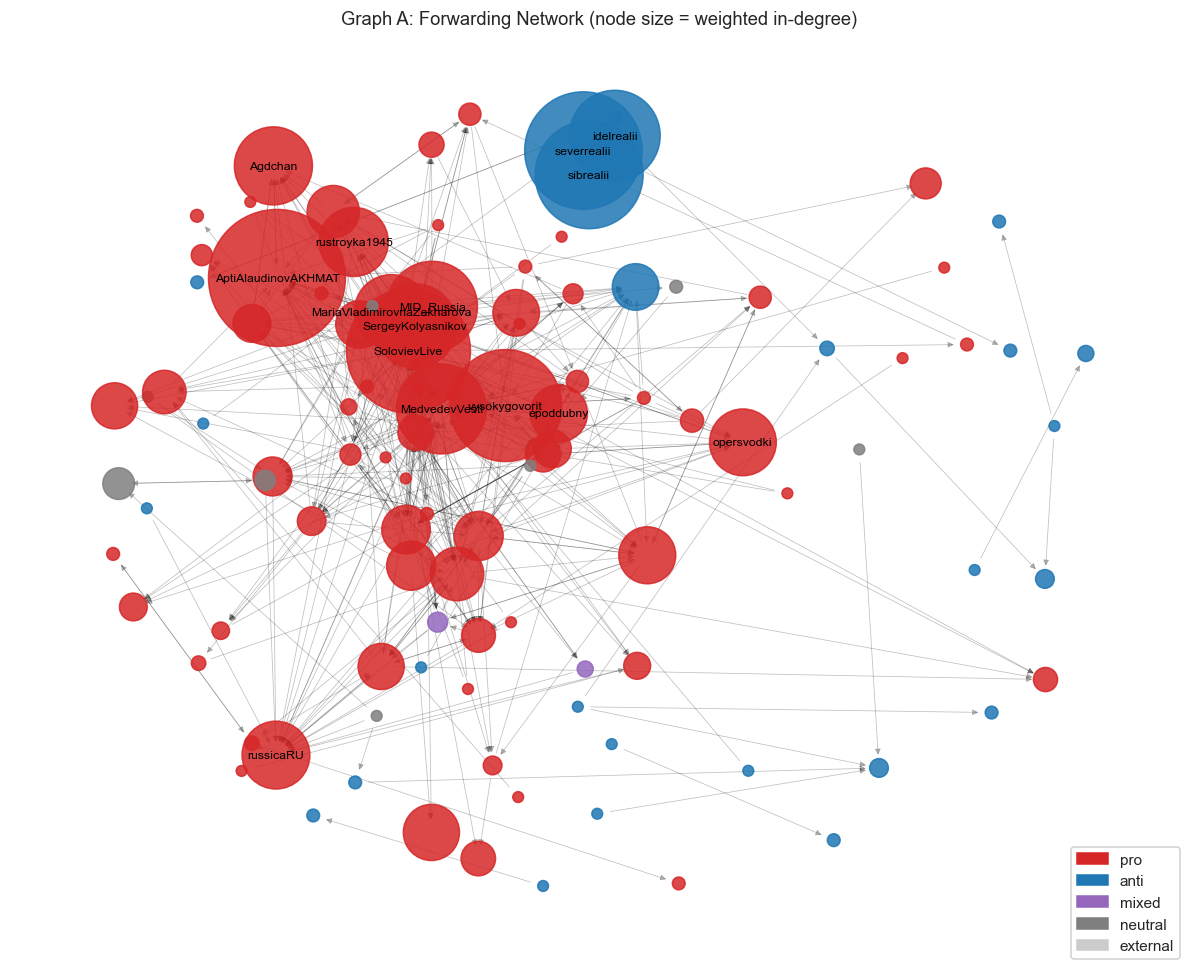

In [14]:
fig, ax = plt.subplots(figsize=(11, 9))
H = G_A.copy()
H.remove_nodes_from([n for n, d in H.degree() if d == 0])
pos = nx.spring_layout(H, k=0.7, seed=RNG_SEED)
lean_colors = {"pro": "#d62728", "anti": "#1f77b4", "mixed": "#9467bd",
               "neutral": "#7f7f7f", "external": "#cccccc", "unknown": "#cccccc"}
node_colors = [lean_colors.get(H.nodes[n].get("lean", "unknown"), "#cccccc") for n in H.nodes()]
node_sizes = [50 + 20 * H.in_degree(n, weight="weight") for n in H.nodes()]
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(H, pos, alpha=0.25, arrowsize=8, width=0.5, ax=ax)
top_nodes = sorted(H.nodes(), key=lambda n: H.in_degree(n, weight="weight"), reverse=True)[:15]
nx.draw_networkx_labels(H, pos, labels={n: n for n in top_nodes}, font_size=8, ax=ax)
from matplotlib.patches import Patch
legend = [Patch(color=c, label=l) for l, c in lean_colors.items() if l != "unknown"]
ax.legend(handles=legend, loc="lower right", framealpha=0.9)
ax.set_title("Graph A: Forwarding Network (node size = weighted in-degree)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_A_forwarding.png", dpi=140, bbox_inches="tight")
plt.show()

The visual confirms what we would expect: pro-Kremlin channels (red) form a dense,
highly interconnected core, while anti-Kremlin channels (blue) cluster in a separate
component on the left. The RFE/RL regional channels (severrealii, sibrealii, idelrealii)
are visibly isolated from the pro-government mass, forwarding almost exclusively
from each other.

## 2.1.5 Export GraphMLs for Gephi

In [15]:
nx.write_graphml(G_A, OUT_DIR / "graph_A_forwarding.graphml")
nx.write_graphml(G_B, OUT_DIR / "graph_B_url_cosharing.graphml")
nx.write_graphml(G_C, OUT_DIR / "graph_C_temporal_coposting.graphml")
print("GraphML exports saved (in Gephi: ForceAtlas2 layout, color=lean, size=eigenvector centrality)")

GraphML exports saved (in Gephi: ForceAtlas2 layout, color=lean, size=eigenvector centrality)


# Section 2.2: SNA Metrics

We compute both node-level and graph-level metrics on Graph A (the forwarding
network). Node-level centrality measures identify hubs, bridges, and influential
sources. Graph-level statistics characterize the overall topology and let us
compare the real network against classical random graph models.

## 2.2.1 Node-level metrics (Graph A)

In [16]:
metrics = pd.DataFrame(index=list(G_A.nodes()))
metrics["in_degree_w"] = pd.Series(dict(G_A.in_degree(weight="weight")))
metrics["out_degree_w"] = pd.Series(dict(G_A.out_degree(weight="weight")))
metrics["betweenness"] = pd.Series(nx.betweenness_centrality(G_A, normalized=True))
metrics["pagerank"] = pd.Series(nx.pagerank(G_A, weight="weight"))
try:
    metrics["eigenvector"] = pd.Series(nx.eigenvector_centrality_numpy(G_A, weight="weight"))
except Exception:
    metrics["eigenvector"] = 0.0
metrics["clustering"] = pd.Series(nx.clustering(G_A.to_undirected()))
metrics = metrics.merge(seeds.set_index("username")[["display_name", "lean", "subcategory"]],
                        left_index=True, right_index=True, how="left")

print("Top-10 by PageRank (information sources):")
print(metrics.nlargest(10, "pagerank")[["display_name", "lean", "pagerank", "in_degree_w"]])
print("\nTop-10 by Betweenness (bridges between communities):")
print(metrics.nlargest(10, "betweenness")[["display_name", "lean", "betweenness"]])
print("\nTop-10 by Out-Degree (most active forwarders):")
print(metrics.nlargest(10, "out_degree_w")[["display_name", "lean", "out_degree_w"]])

Top-10 by PageRank (information sources):
                             display_name lean  pagerank  in_degree_w
AptiAlaudinovAKHMAT  Апти Алаудинов АХМАТ  pro  0.081169          399
SolovievLive                     СОЛОВЬЁВ  pro  0.069259          327
obrazbuduschego2           Образ будущего  pro  0.066988           43
russicaRU                        НЕЗЫГАРЬ  pro  0.064452           96
MedvedevVesti             Андрей Медведев  pro  0.054655          171
vysokygovorit                 Старше Эдды  pro  0.033690          266
mig41                          МИГ России  pro  0.030540           48
SergeyKolyasnikov                ZERGULIO  pro  0.028517          149
Agdchan                   Александр Дугин  pro  0.027326          128
rustroyka1945                      ТРОЙКА  pro  0.023707          100

Top-10 by Betweenness (bridges between communities):
                                            display_name lean  betweenness
SolovievLive                                    СОЛОВЬЁВ  p

Several observations stand out here. First, the top PageRank nodes are *all* pro-Kremlin.
This is not just because there are more pro channels in the dataset: PageRank accounts
for link structure, and pro-government channels actively forward from each other,
reinforcing mutual authority. Second, betweenness centrality highlights channels that
connect otherwise separate parts of the network. Solovyov ranks first here, which makes
sense: as a major TV host, he is referenced by military bloggers, political analysts,
and official government channels alike.

## 2.2.2 Graph-level metrics

In [17]:
def graph_metrics(g, name):
    print(f"\n=== {name} ===")
    print(f"  Nodes / Edges:      {g.number_of_nodes()} / {g.number_of_edges()}")
    print(f"  Density:            {nx.density(g):.4f}")
    if g.is_directed():
        print(f"  Reciprocity:        {nx.reciprocity(g):.4f}")
    if g.is_directed():
        wcc = list(nx.weakly_connected_components(g))
        scc = list(nx.strongly_connected_components(g))
        print(f"  Weakly connected:   {len(wcc)} (largest {max(len(c) for c in wcc)})")
        print(f"  Strongly connected: {len(scc)} (largest {max(len(c) for c in scc)})")
        largest = max(wcc, key=len)
        sub = g.subgraph(largest).to_undirected()
    else:
        ccs = list(nx.connected_components(g))
        print(f"  Connected comps:    {len(ccs)} (largest {max(len(c) for c in ccs)})")
        largest = max(ccs, key=len)
        sub = g.subgraph(largest)
    if sub.number_of_nodes() > 1 and sub.number_of_edges() > 0:
        try:
            print(f"  Diameter (largest CC):       {nx.diameter(sub)}")
            print(f"  Avg path length (largest):   {nx.average_shortest_path_length(sub):.3f}")
        except Exception as e:
            print(f"  Path metrics skipped: {e}")
    try:
        print(f"  Degree assortativity:        {nx.degree_assortativity_coefficient(g):.4f}")
    except Exception:
        pass

graph_metrics(G_A, "Graph A: Forwarding")
graph_metrics(G_B, "Graph B: URL Co-sharing")
graph_metrics(G_C, "Graph C: Temporal Co-posting")


=== Graph A: Forwarding ===
  Nodes / Edges:      144 / 463
  Density:            0.0225
  Reciprocity:        0.2549
  Weakly connected:   36 (largest 104)
  Strongly connected: 91 (largest 48)
  Diameter (largest CC):       11
  Avg path length (largest):   3.666
  Degree assortativity:        -0.0532

=== Graph B: URL Co-sharing ===
  Nodes / Edges:      144 / 2827
  Density:            0.2746
  Connected comps:    10 (largest 135)


  Diameter (largest CC):       4


  Avg path length (largest):   1.763
  Degree assortativity:        -0.1466

=== Graph C: Temporal Co-posting ===
  Nodes / Edges:      144 / 710
  Density:            0.0690
  Connected comps:    25 (largest 120)


  Diameter (largest CC):       5
  Avg path length (largest):   2.382
  Degree assortativity:        -0.1052


The forwarding network (A) has low density (0.022) but its largest weakly connected
component spans 104 of 144 channels, showing that most channels are reachable through
forwarding chains. Reciprocity is 0.25: about a quarter of forwarding relationships
are mutual, suggesting editorial partnerships rather than one-way consumption.
Negative degree assortativity across all three graphs means that high-degree hubs
tend to connect to low-degree periphery nodes (a typical pattern in broadcast-style
information networks).

## 2.2.3 Power-law degree distribution

If the degree distribution follows a power law, the network has a scale-free property:
a few hubs dominate the connectivity while most nodes have very few links. This is
a hallmark of preferential attachment in social and information networks.

Power-law fit on Graph A degree:
  alpha (exponent):    2.120
  x_min:               5.0
  Power-law vs exponential: R=-2.098, p=0.0359  -> inconclusive


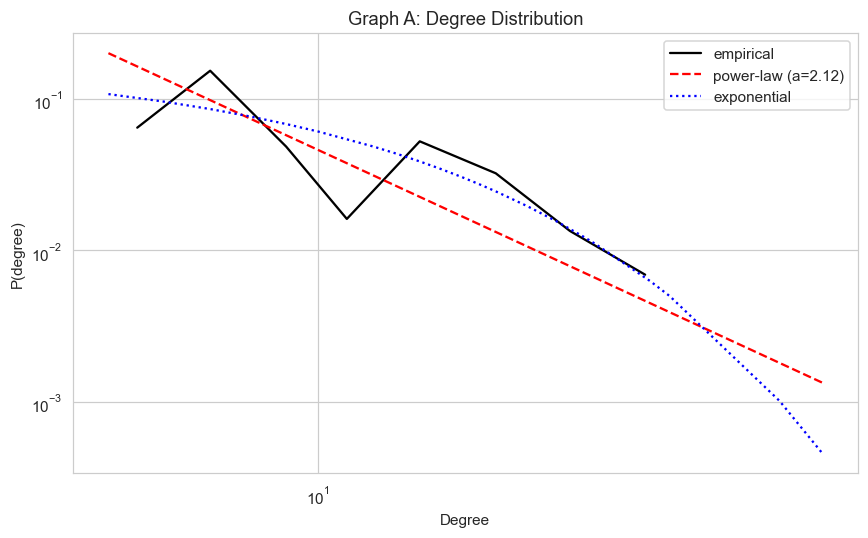

In [18]:
import powerlaw

degs = np.array([d for n, d in G_A.degree() if d > 0])
fit = powerlaw.Fit(degs, discrete=True, verbose=False)
print(f"Power-law fit on Graph A degree:")
print(f"  alpha (exponent):    {fit.alpha:.3f}")
print(f"  x_min:               {fit.xmin}")
R, p = fit.distribution_compare("power_law", "exponential", normalized_ratio=True)
print(f"  Power-law vs exponential: R={R:.3f}, p={p:.4f}  -> {'power-law preferred' if R > 0 and p < 0.1 else 'inconclusive'}")

fig, ax = plt.subplots(figsize=(8, 5))
fit.plot_pdf(ax=ax, color="black", label="empirical")
fit.power_law.plot_pdf(ax=ax, color="red", linestyle="--", label=f"power-law (a={fit.alpha:.2f})")
fit.exponential.plot_pdf(ax=ax, color="blue", linestyle=":", label="exponential")
ax.set_xlabel("Degree"); ax.set_ylabel("P(degree)")
ax.set_title("Graph A: Degree Distribution")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "degree_distribution.png", dpi=140)
plt.show()

the formal power-law-vs-exponential test is inconclusive given the small network (n=144), but the degree distribution is clearly heavy-tailed (α≈2.1), consistent with an approximately scale-free, hub-dominated structure.

## 2.2.4 Comparison with random graph models (Erdos-Renyi, Barabasi-Albert)

To confirm that the observed network structure is non-random, we generate two null
models with the same number of nodes and a comparable number of edges:
Erdos-Renyi (uniform random connections) and Barabasi-Albert (preferential attachment).

Model comparison:
          model   n   m  density  clustering  max_degree  avg_degree
 Real (Graph A) 144 463 0.022484    0.251094          28    3.215278
    Erdos-Renyi 144 434 0.021076    0.046286           8    3.013889
Barabasi-Albert 144 423 0.041084    0.131972          38    5.875000


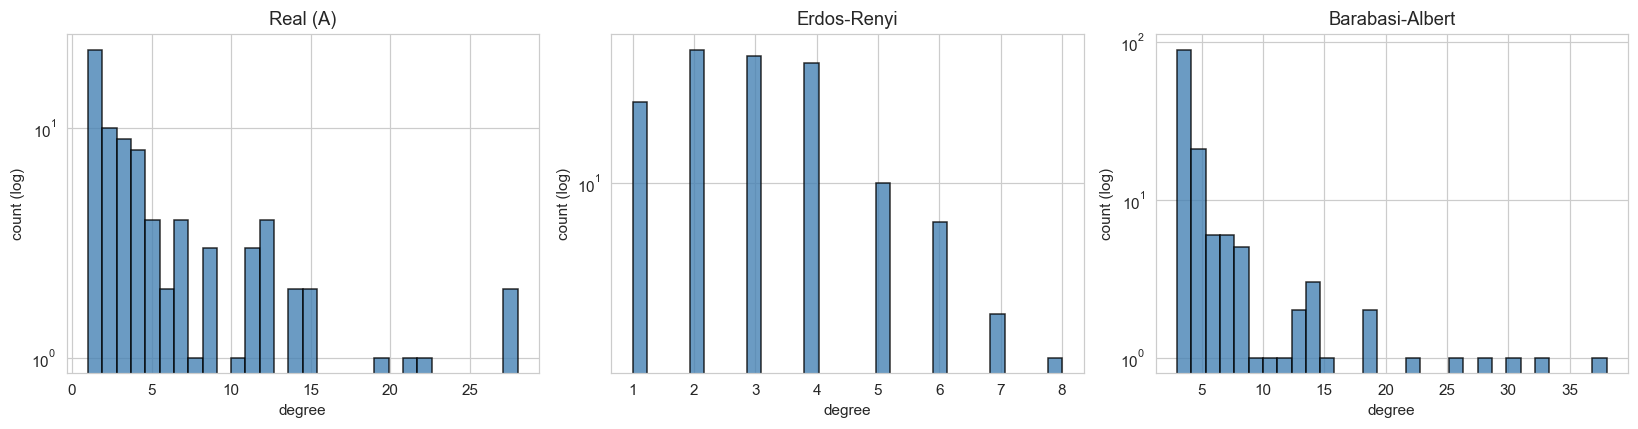

In [19]:
n, m = G_A.number_of_nodes(), G_A.number_of_edges()

G_er = nx.erdos_renyi_graph(n, p=m / (n * (n - 1)), seed=RNG_SEED, directed=True)
m_attach = max(1, m // n)
G_ba = nx.barabasi_albert_graph(n, m=m_attach, seed=RNG_SEED)

def quick_stats(g, label):
    deg = [d for n, d in (g.degree() if not g.is_directed() else g.in_degree())]
    return {
        "model":       label,
        "n":           g.number_of_nodes(),
        "m":           g.number_of_edges(),
        "density":     nx.density(g),
        "clustering":  nx.average_clustering(g.to_undirected() if g.is_directed() else g),
        "max_degree":  max(deg) if deg else 0,
        "avg_degree":  np.mean(deg) if deg else 0,
    }

comp = pd.DataFrame([
    quick_stats(G_A, "Real (Graph A)"),
    quick_stats(G_er, "Erdos-Renyi"),
    quick_stats(G_ba, "Barabasi-Albert"),
])
print("Model comparison:")
print(comp.to_string(index=False))

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, (g, label) in zip(axs, [(G_A, "Real (A)"), (G_er, "Erdos-Renyi"), (G_ba, "Barabasi-Albert")]):
    deg = [d for _, d in (g.degree() if not g.is_directed() else g.in_degree()) if d > 0]
    ax.hist(deg, bins=30, log=True, color="steelblue", edgecolor="k", alpha=0.8)
    ax.set_title(label); ax.set_xlabel("degree"); ax.set_ylabel("count (log)")
plt.tight_layout()
plt.savefig(OUT_DIR / "model_comparison.png", dpi=140)
plt.show()

The key finding here is the **clustering coefficient**: the real network (0.251) is
roughly 5x more clustered than Erdos-Renyi (0.046) and about 2x more than
Barabasi-Albert (0.132). This elevated clustering is the quantitative fingerprint
of echo chambers: channels do not just connect to random hubs, they form tight
in-groups where everyone forwards everyone else. The degree distribution of the real
network is clearly heavy-tailed (like BA, unlike ER), confirming hub-dominated
structure. In other words, the real forwarding network combines the heavy tail
of preferential attachment with much stronger local clustering than either null
model can explain.

# Section 2.3: Community Detection 

We apply three community detection methods to the forwarding network:
Louvain (modularity optimization), Infomap (information-theoretic), and
k-clique percolation (which allows overlapping membership). We then validate
the detected communities against our manually assigned lean labels using NMI.

## 2.3.1 Louvain

In [20]:
import community
print(community.__file__)
print(dir(community)[:30])

C:\Users\goog\AppData\Roaming\Python\Python312\site-packages\community\__init__.py
['__author__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'best_partition', 'community_louvain', 'community_status', 'generate_dendrogram', 'induced_graph', 'load_binary', 'modularity', 'partition_at_level']


In [21]:
import sys
!{sys.executable} -m pip uninstall -y community
!{sys.executable} -m pip uninstall -y python-louvain
!{sys.executable} -m pip install python-louvain

'C:\Program' is not recognized as an internal or external command,
operable program or batch file.


'C:\Program' is not recognized as an internal or external command,
operable program or batch file.


'C:\Program' is not recognized as an internal or external command,
operable program or batch file.


In [22]:
import community as community_louvain

G_A_un = G_A.to_undirected()
louvain_part = community_louvain.best_partition(G_A_un, weight="weight", random_state=RNG_SEED)
louvain_mod = community_louvain.modularity(louvain_part, G_A_un, weight="weight")
metrics["louvain"] = pd.Series(louvain_part)
print(f"Louvain: {len(set(louvain_part.values()))} communities, modularity = {louvain_mod:.4f}")

Louvain: 43 communities, modularity = 0.6312


## 2.3.2 Infomap (via igraph)

In [23]:
import igraph as ig

mapping = {n: i for i, n in enumerate(G_A.nodes())}
reverse = {i: n for n, i in mapping.items()}
ig_edges = [(mapping[u], mapping[v]) for u, v in G_A.edges()]
ig_weights = [G_A[u][v]["weight"] for u, v in G_A.edges()]
g_ig = ig.Graph(n=len(mapping), edges=ig_edges, directed=True)
g_ig.es["weight"] = ig_weights

try:
    infomap_clusters = g_ig.community_infomap(edge_weights="weight")
    infomap_part = {reverse[i]: c for i, c in enumerate(infomap_clusters.membership)}
    metrics["infomap"] = pd.Series(infomap_part)
    print(f"Infomap: {len(set(infomap_part.values()))} communities, codelength = {infomap_clusters.codelength:.4f}")
except Exception as e:
    print(f"Infomap skipped: {e}")
    metrics["infomap"] = -1

Infomap: 49 communities, codelength = 3.8298


## 2.3.3 Overlapping community detection (k-clique)

Louvain and Infomap assign each channel to exactly one community. But in practice,
some channels act as bridges and should belong to multiple groups. The k-clique
method finds overlapping communities by looking for groups of fully-connected
subgraphs (cliques) that share members.

In [24]:
from networkx.algorithms.community import k_clique_communities

K = 3
overlap_comms = list(k_clique_communities(G_A_un, k=K))
print(f"k-clique (k={K}): {len(overlap_comms)} overlapping communities")

node_to_comms = defaultdict(set)
for i, c in enumerate(overlap_comms):
    for n in c:
        node_to_comms[n].add(i)

bridges = {n: comms for n, comms in node_to_comms.items() if len(comms) > 1}
print(f"\nBridge channels (belong to >=2 communities):")
for n, comms in sorted(bridges.items(), key=lambda x: -len(x[1]))[:10]:
    nm = seeds[seeds["username"] == n]["display_name"].values
    name = nm[0] if len(nm) else n
    ln = metrics.loc[n, "lean"] if n in metrics.index else "?"
    print(f"  {name:<30} ({ln}): communities {comms}")

k-clique (k=3): 2 overlapping communities

Bridge channels (belong to >=2 communities):


## 2.3.4 NMI vs ground-truth lean labels

We compare the algorithmically detected communities against our manual lean
annotations using Normalized Mutual Information (NMI). NMI = 1 would mean
communities perfectly match lean labels; NMI = 0 would mean no correlation.

In [25]:
from sklearn.metrics import normalized_mutual_info_score

valid = metrics.dropna(subset=["lean"])
valid = valid[valid["lean"].isin(["pro", "anti", "mixed", "neutral"])]
nmi_louvain = normalized_mutual_info_score(valid["lean"], valid["louvain"])
print(f"NMI(Louvain, lean_truth)  = {nmi_louvain:.4f}")
if "infomap" in metrics.columns:
    nmi_infomap = normalized_mutual_info_score(valid["lean"], valid["infomap"])
    print(f"NMI(Infomap, lean_truth)  = {nmi_infomap:.4f}")

NMI(Louvain, lean_truth)  = 0.3586
NMI(Infomap, lean_truth)  = 0.3571


NMI around 0.35 tells us that political lean explains part of the community
structure, but not all of it. The detected communities capture finer distinctions:
pro-Kremlin channels split into subclusters based on their focus (military bloggers
vs. state officials vs. political analysts), and anti-Kremlin channels separate by
media affiliation (RFE/RL vs. independent journalists). This is actually a positive
result: it means community detection is picking up meaningful sub-structure beyond
our coarse 3-way labelling.

## 2.3.5 Community composition table

In [26]:
comp_table = pd.crosstab(valid["louvain"], valid["lean"]).sort_values(by=list(valid["lean"].unique()), ascending=False)
print("Louvain communities x lean composition:")
print(comp_table.head(20))

purity = comp_table.div(comp_table.sum(axis=1), axis=0)
purity["dominant_lean"] = comp_table.idxmax(axis=1)
purity["size"] = comp_table.sum(axis=1)
purity = purity[purity["size"] >= 3].sort_values("size", ascending=False)
print(f"\nCommunities with size >= 3, by dominant lean:")
print(purity)

Louvain communities x lean composition:
lean     anti  mixed  neutral  pro
louvain                           
16          9      0        4    0
0           5      0        0    0
12          3      0        0    0
15          2      0        2   11
3           2      0        0    0
20          2      0        0    0
31          2      0        0    0
9           1      0        0   19
5           1      2        3   18
6           1      0        0    0
7           1      0        0    0
10          1      0        0    0
19          1      0        0    0
21          1      0        0    0
22          1      0        0    0
28          1      0        0    0
29          1      0        0    0
33          1      0        0    0
35          1      0        0    0
40          1      0        0    0

Communities with size >= 3, by dominant lean:
lean         anti     mixed   neutral       pro dominant_lean  size
louvain                                                            
5      

## 2.3.6 Community visualization and GraphML re-export

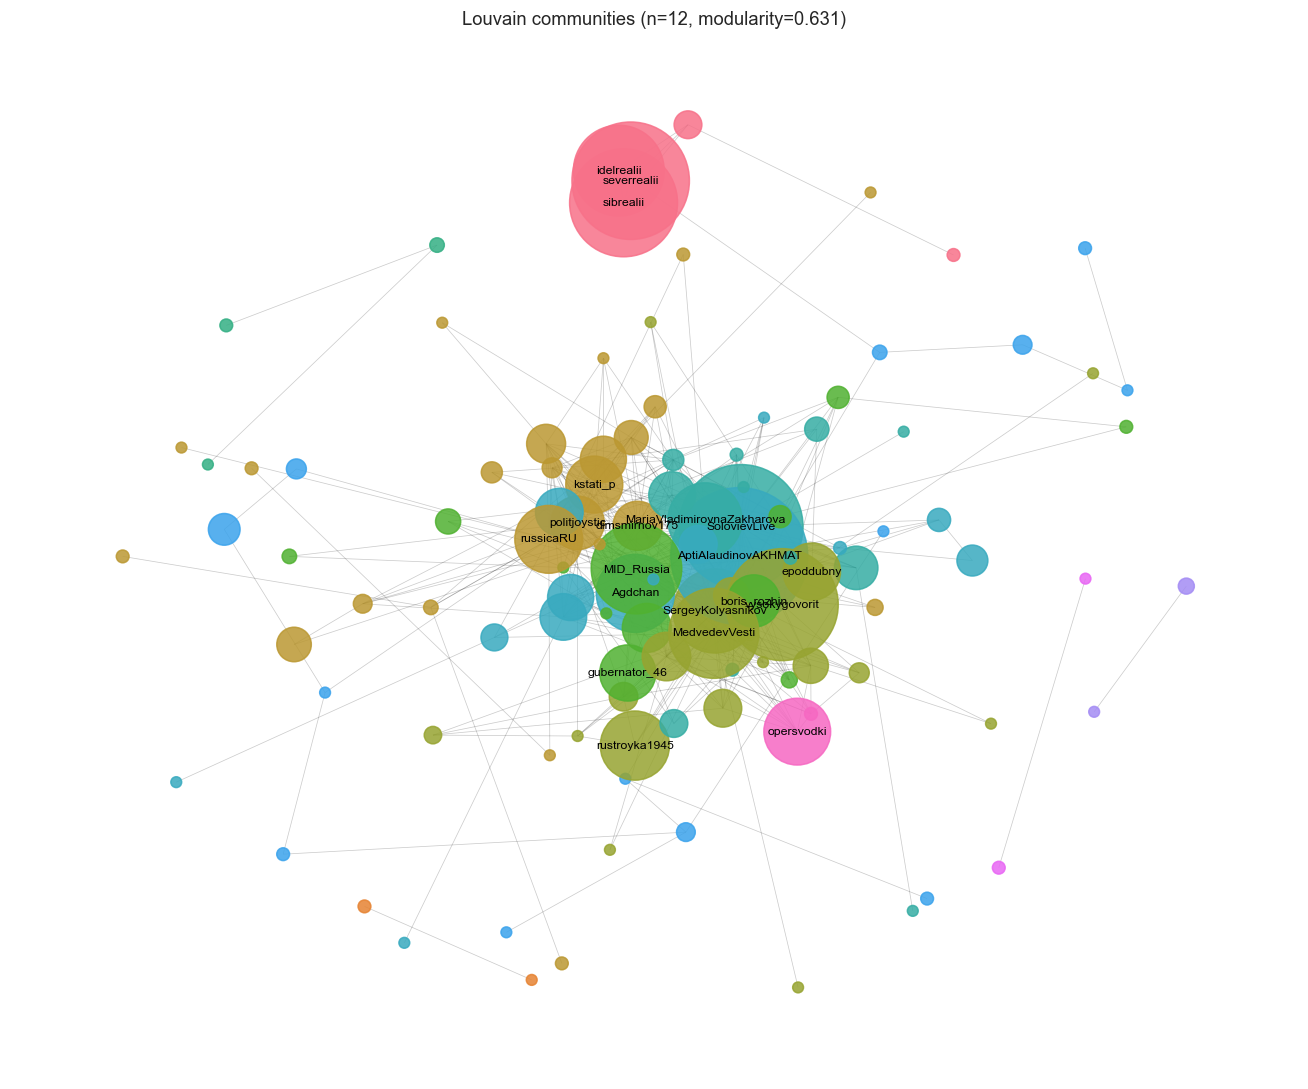

In [27]:
fig, ax = plt.subplots(figsize=(12, 10))
H = G_A_un.copy()
H.remove_nodes_from([n for n, d in H.degree() if d == 0])
pos = nx.spring_layout(H, k=0.6, seed=RNG_SEED)
comm_ids = sorted(set(louvain_part[n] for n in H.nodes()))
palette = sns.color_palette("husl", len(comm_ids))
comm_color = {c: palette[i] for i, c in enumerate(comm_ids)}
node_colors = [comm_color[louvain_part[n]] for n in H.nodes()]
node_sizes = [50 + 20 * G_A.in_degree(n, weight="weight") for n in H.nodes()]
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(H, pos, alpha=0.2, width=0.5, ax=ax)
top_nodes = sorted(H.nodes(), key=lambda n: G_A.in_degree(n, weight="weight"), reverse=True)[:20]
nx.draw_networkx_labels(H, pos, labels={n: n for n in top_nodes}, font_size=8, ax=ax)
ax.set_title(f"Louvain communities (n={len(comm_ids)}, modularity={louvain_mod:.3f})")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_DIR / "communities_louvain.png", dpi=140, bbox_inches="tight")
plt.show()

In [28]:
# Re-export GraphMLs with community IDs as node attributes (for Gephi coloring)
for n in G_A.nodes():
    G_A.nodes[n]["louvain"] = int(louvain_part.get(n, -1))
    G_A.nodes[n]["infomap"] = int(infomap_part.get(n, -1)) if isinstance(infomap_part, dict) else -1

for G, name in [(G_A, "graph_A_forwarding"),
                (G_B, "graph_B_url_cosharing"),
                (G_C, "graph_C_temporal_coposting")]:
    if G is not G_A:
        for n in G.nodes():
            G.nodes[n]["louvain"] = int(louvain_part.get(n, -1))
            G.nodes[n]["infomap"] = int(infomap_part.get(n, -1)) if isinstance(infomap_part, dict) else -1
    nx.write_graphml(G, OUT_DIR / f"{name}.graphml")
print("GraphMLs re-exported with community attributes")

GraphMLs re-exported with community attributes


# Section 2.4: Coordination / CIB Detection

We define a composite coordination score for each channel pair:

$$\text{coord\_score}(A, B) = \alpha \cdot \text{fwd\_sim} + \beta \cdot \text{url\_sim}
+ \gamma \cdot \text{temp\_sim} + \delta \cdot \text{near\_dup\_sim}$$

The weights ($\alpha = \beta = \gamma = 0.3$, $\delta = 0.1$) give equal importance
to forwarding, URL overlap, and temporal synchrony, with a smaller contribution from
textual near-duplicates (which are noisier).

In [29]:
ALPHA, BETA, GAMMA, DELTA = 0.3, 0.3, 0.3, 0.1

pairs = list(combinations(sorted(seed_users), 2))
print(f"Pairs to evaluate: {len(pairs):,}")

ch_urls_norm = urls_filt[urls_filt["channel_username"].isin(seed_users)].groupby("channel_username")["url_norm"].apply(set).to_dict()
fwd_dict = defaultdict(lambda: defaultdict(int))
for r in fwd_edges.itertuples():
    if r.forwarded_from in seed_users and r.channel_username in seed_users:
        fwd_dict[r.forwarded_from][r.channel_username] = r.weight
        fwd_dict[r.channel_username][r.forwarded_from] += r.weight

temp_dict = {tuple(sorted([a, b])): v for (a, b), v in temp_coshare.items()}
near_dup_count = near_dup_df.groupby(["src_ch", "tgt_ch"]).size().to_dict() if len(near_dup_df) else {}
msg_count = messages.groupby("channel_username").size().to_dict()

Pairs to evaluate: 10,296


In [30]:
records = []
for a, b in pairs:
    url_inter = len(ch_urls_norm.get(a, set()) & ch_urls_norm.get(b, set()))
    url_union = len(ch_urls_norm.get(a, set()) | ch_urls_norm.get(b, set())) or 1
    url_sim = url_inter / url_union

    fwd_ab = fwd_dict.get(a, {}).get(b, 0) + fwd_dict.get(b, {}).get(a, 0)
    fwd_norm = fwd_ab / max(1, np.log1p(msg_count.get(a, 1) * msg_count.get(b, 1)))
    fwd_sim = min(1.0, fwd_norm)

    temp_sim = temp_dict.get((a, b), 0) / max(1, url_union) if url_inter else 0

    nd = near_dup_count.get((a, b), 0) + near_dup_count.get((b, a), 0)
    nd_sim = nd / max(1, min(msg_count.get(a, 1), msg_count.get(b, 1)))

    score = ALPHA * fwd_sim + BETA * url_sim + GAMMA * temp_sim + DELTA * nd_sim

    records.append({
        "a": a, "b": b,
        "fwd_sim": fwd_sim, "url_sim": url_sim,
        "temp_sim": temp_sim, "near_dup_sim": nd_sim,
        "coord_score": score,
    })

coord_df = pd.DataFrame(records).sort_values("coord_score", ascending=False)
coord_df.to_pickle(OUT_DIR / "coord_scores.pkl")
print(f"Top 20 suspicious pairs (high coordination score):")
top = coord_df.head(20).copy()
top["a_name"] = top["a"].map(seeds.set_index("username")["display_name"])
top["b_name"] = top["b"].map(seeds.set_index("username")["display_name"])
top["a_lean"] = top["a"].map(seeds.set_index("username")["lean"])
top["b_lean"] = top["b"].map(seeds.set_index("username")["lean"])
print(top[["a_name", "a_lean", "b_name", "b_lean", "coord_score", "fwd_sim", "url_sim", "temp_sim"]].to_string(index=False))

Top 20 suspicious pairs (high coordination score):
                            a_name a_lean                       b_name b_lean  coord_score  fwd_sim  url_sim  temp_sim
                      Север.Реалии   anti                Сибирь.Реалии   anti     0.581883      1.0 0.342072  0.433833
                  Вячеслав Володин    pro                  Старше Эдды    pro     0.412785      1.0 0.038339  0.207668
               Навстречу Трансферу    pro              Друзья Дональда    pro     0.408067      1.0 0.195122  0.158537
            Неофициальный Безсонов    pro           Оперативные сводки    pro     0.401153      1.0 0.142458  0.173184
              Апти Алаудинов АХМАТ    pro                     СОЛОВЬЁВ    pro     0.368164      1.0 0.014308  0.181558
                           СЛУЦКИЙ    pro                  Старше Эдды    pro     0.365940      1.0 0.075377  0.092965
                       Idel.Реалии   anti                 Север.Реалии   anti     0.365572      1.0 0.109359  0.0452

The highest-scoring pair is Sever.Realii / Sibir.Realii (0.58), which are both
RFE/RL regional desks sharing a common editorial pipeline. The MID Russia / Zakharova
pair (0.37) reflects an institutional link: Zakharova is MID's spokesperson and
her channel essentially mirrors the ministry's posts. The Alaudinov / Solovyov
pair (0.37) connects a military figure with a TV propagandist, suggesting
cross-domain coordination between the military and media wings of the pro-Kremlin
ecosystem.

## 2.4.1 Coordination heatmap

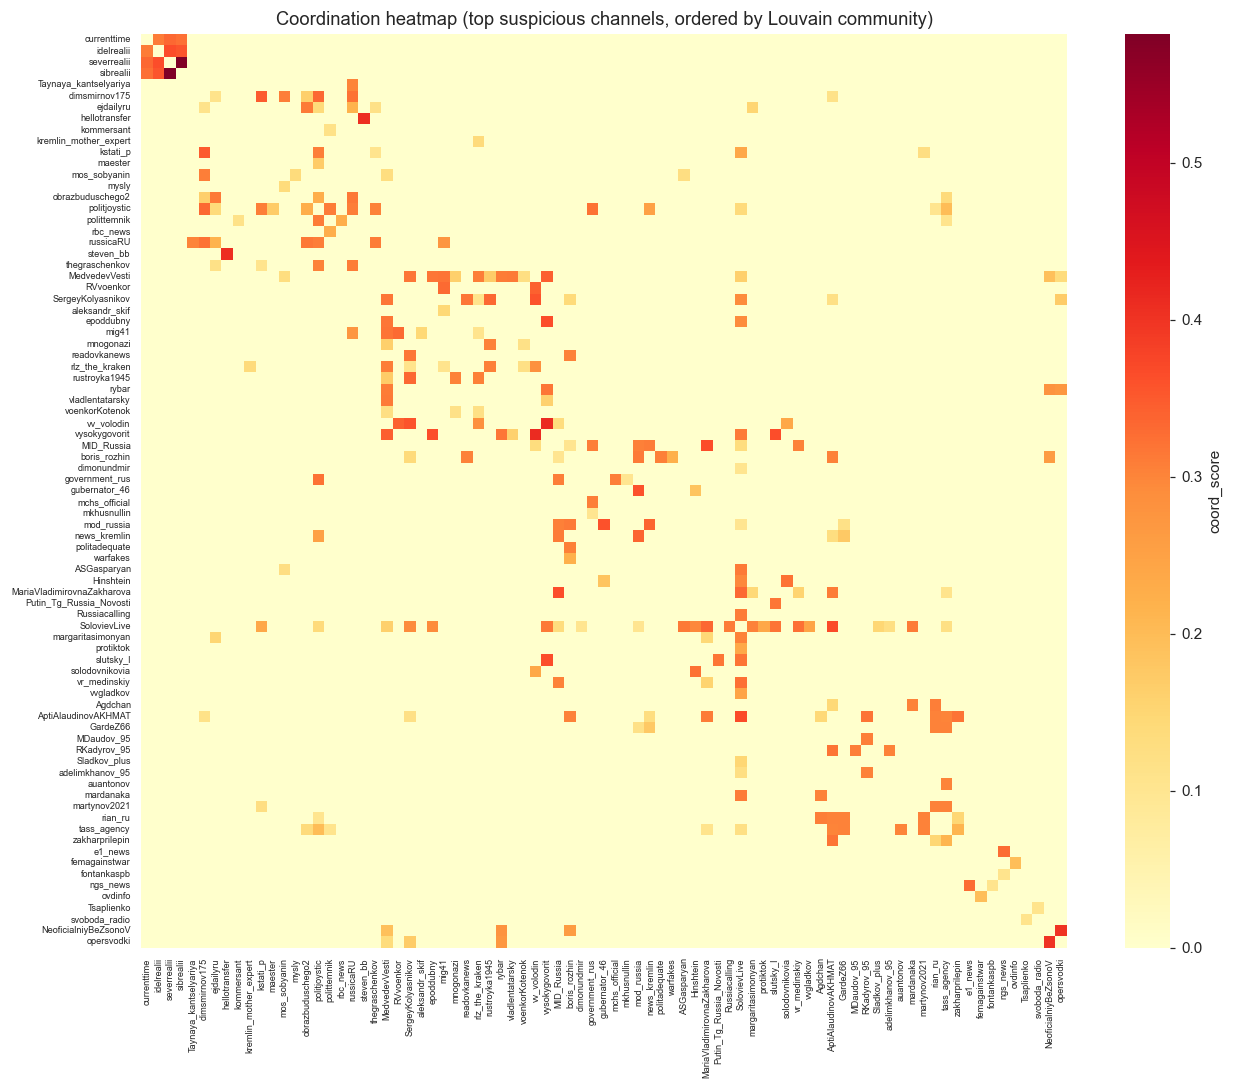

In [31]:
top_pairs = coord_df.head(150)
all_nodes = list(set(top_pairs["a"]) | set(top_pairs["b"]))
matrix = pd.DataFrame(0.0, index=all_nodes, columns=all_nodes)
for r in top_pairs.itertuples():
    matrix.loc[r.a, r.b] = r.coord_score
    matrix.loc[r.b, r.a] = r.coord_score

if "louvain" in metrics.columns:
    order = sorted(all_nodes, key=lambda n: (metrics.loc[n, "louvain"] if n in metrics.index else -1, n))
    matrix = matrix.loc[order, order]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(matrix, cmap="YlOrRd", cbar_kws={"label": "coord_score"}, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title("Coordination heatmap (top suspicious channels, ordered by Louvain community)")
plt.xticks(rotation=90, fontsize=6); plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig(OUT_DIR / "coordination_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()

Bright squares along the diagonal correspond to within-community coordination, which
is expected: channels in the same cluster naturally share content. The more interesting
signals are bright spots *off* the diagonal blocks, which suggest cross-community
coordination worth investigating further.

---
# Section 3: Content Analysis

The network analysis above tells us *who talks to whom*. Content analysis asks
*what they say* and *how they say it*. We apply three NLP pipelines to the full
corpus (sentiment, emotion, named entity recognition) and complement them with
topic modeling and aspect-based sentiment analysis.

NLP results were pre-computed by `nlp_pipeline.py` and stored in a separate SQLite
database (`wsa_nlp.db`). We attach it here and load the results.

## 3.0 Load NLP results

In [32]:
NLP_DB_PATH = Path("wsa_nlp.db")
if NLP_DB_PATH.exists():
    conn.execute(f"ATTACH DATABASE '{NLP_DB_PATH}' AS nlp")
    _p = "nlp."
    print(f"Attached {NLP_DB_PATH} ({NLP_DB_PATH.stat().st_size / 1e6:.0f} MB)")
else:
    _p = ""
    print("NLP tables in main DB")

sent = pd.read_sql_query(f"SELECT * FROM {_p}msg_sentiment", conn)
emo  = pd.read_sql_query(f"SELECT * FROM {_p}msg_emotion", conn)
ents = pd.read_sql_query(f"SELECT * FROM {_p}msg_entities", conn)
print(f"Sentiment rows: {len(sent):,}")
print(f"Emotion rows:   {len(emo):,}")
print(f"Entity rows:    {len(ents):,}")

Attached wsa_nlp.db (470 MB)


Sentiment rows: 408,057
Emotion rows:   408,057
Entity rows:    3,298,181


In [33]:
# Merge with lean labels and timestamps
lean_map = seeds.set_index("username")["lean"].to_dict()

sent["lean"] = sent["channel_username"].map(lean_map)
emo["lean"]  = emo["channel_username"].map(lean_map)
ents["lean"] = ents["channel_username"].map(lean_map)

# Add timestamps from messages for temporal analysis
ts_map = messages.set_index(["channel_username", "msg_id"])["timestamp"].to_dict()
sent["timestamp"] = sent.apply(lambda r: ts_map.get((r["channel_username"], r["msg_id"])), axis=1)
sent["timestamp"] = pd.to_datetime(sent["timestamp"], utc=True, errors="coerce")
sent = sent.dropna(subset=["timestamp", "lean"])
print(f"Sentiment rows after merge: {len(sent):,}")

Sentiment rows after merge: 389,003


## 3.1 Sentiment Analysis

The sentiment model (`blanchefort/rubert-base-cased-sentiment-rusentiment`) classifies
each message as positive, negative, or neutral. We first look at overall distributions,
then break them down by political lean and over time.

### 3.1.1 Overall sentiment distribution

Overall sentiment distribution:
label
neutral     370059
negative     10932
positive      8012
Name: count, dtype: int64

Neutral share: 95.1%


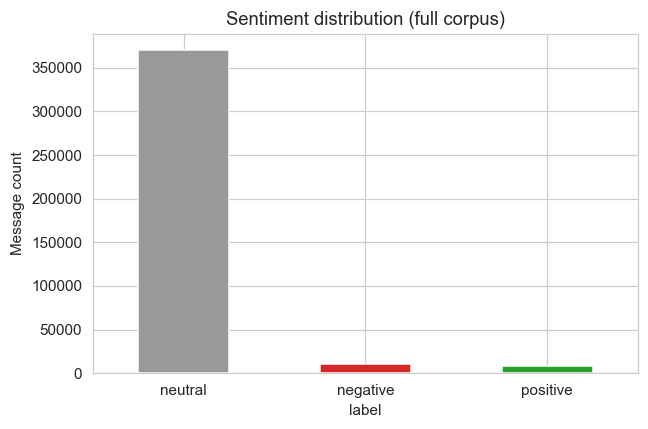

In [34]:
sent_counts = sent["label"].value_counts()
print("Overall sentiment distribution:")
print(sent_counts)
print(f"\nNeutral share: {sent_counts.get('neutral', 0) / len(sent) * 100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
colors = {"neutral": "#999999", "negative": "#d62728", "positive": "#2ca02c"}
sent_counts.plot.bar(color=[colors.get(l, "#999") for l in sent_counts.index], ax=ax)
ax.set_title("Sentiment distribution (full corpus)")
ax.set_ylabel("Message count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "sentiment_distribution.png", dpi=140)
plt.show()

About 95% of messages are classified as neutral. This is a well-documented
limitation of the RuBERT sentiment model on formal, news-style text: it interprets
the impersonal register of news reporting as emotionally flat, even when the content
is politically loaded. This does not mean the channels lack bias. It means that
bias in this ecosystem is expressed through *topic selection* and *framing* rather
than through overt emotional language. We address this limitation with aspect-based
sentiment in Section 3.1.4.

### 3.1.2 Sentiment by lean group

Sentiment proportions by lean (%):
label    negative  neutral  positive
lean                                
anti         2.37    95.65      1.98
mixed        2.45    92.07      5.49
neutral      0.58    98.46      0.96
pro          4.01    93.51      2.48


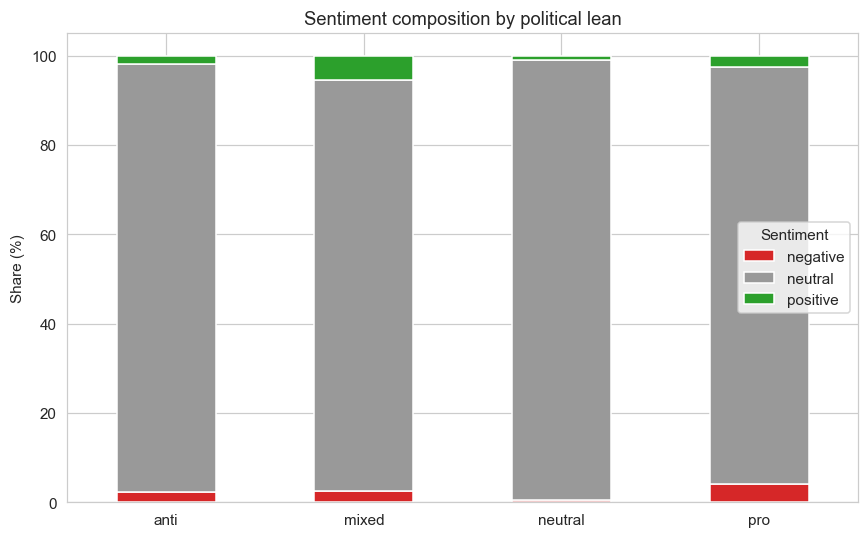

In [35]:
sent_by_lean = pd.crosstab(sent["lean"], sent["label"], normalize="index") * 100
print("Sentiment proportions by lean (%):")
print(sent_by_lean.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sent_by_lean[["negative", "neutral", "positive"]].plot.bar(
    stacked=True, color=["#d62728", "#999999", "#2ca02c"], ax=ax, edgecolor="white"
)
ax.set_title("Sentiment composition by political lean")
ax.set_ylabel("Share (%)")
ax.set_xlabel("")
ax.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "sentiment_by_lean.png", dpi=140)
plt.show()

A counterintuitive finding: **pro-Kremlin channels have the highest rate of
negative sentiment (4.0%)**, exceeding even anti-Kremlin channels (2.4%).
This makes sense on closer inspection: pro-government channels frequently use
aggressive, confrontational language when discussing Western actions, Ukrainian
military operations, and domestic opposition. In contrast, neutral outlets (0.6%
negative) stick closely to the factual register that the model reads as neutral.
The mixed group shows the highest positive rate (5.5%), possibly because channels
like Sobchak blend lifestyle content with politics.

### 3.1.3 Sentiment timeline

We aggregate sentiment weekly by lean group to track whether the emotional tone
of each faction shifts around major events.

C:\Users\goog\AppData\Local\Temp\claude\ipykernel_29316\353848934.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sent["week"] = sent["timestamp"].dt.to_period("W").apply(lambda r: r.start_time)


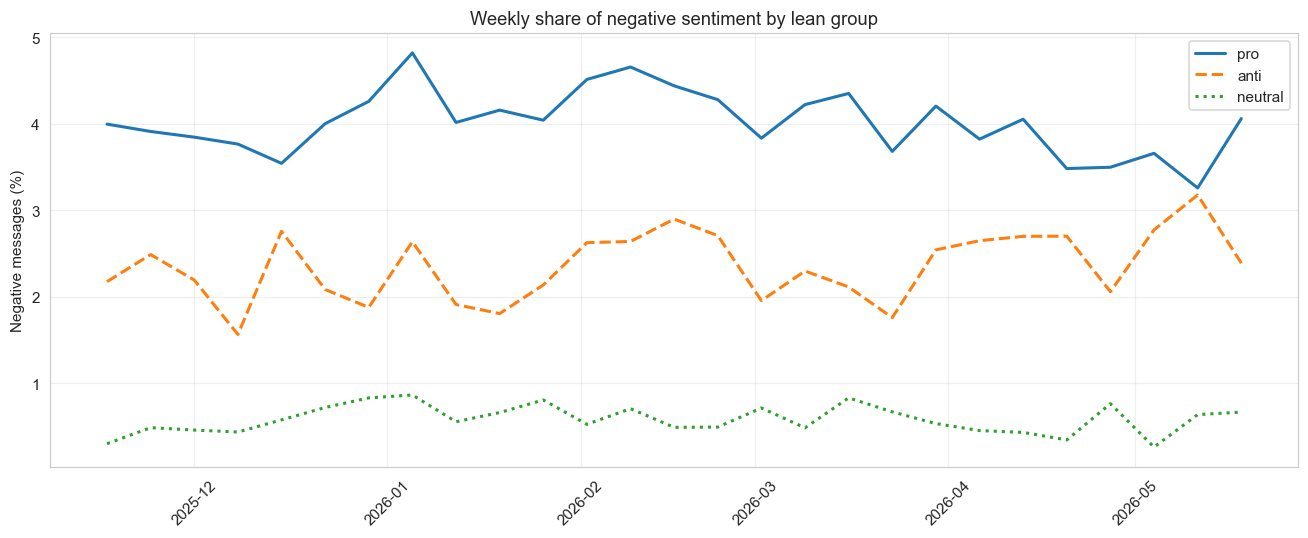

In [36]:
sent["week"] = sent["timestamp"].dt.to_period("W").apply(lambda r: r.start_time)

weekly = (
    sent.groupby(["week", "lean", "label"]).size()
    .unstack(fill_value=0)
    .reset_index()
)
weekly["total"] = weekly[["negative", "neutral", "positive"]].sum(axis=1)
weekly["neg_share"] = weekly["negative"] / weekly["total"] * 100

fig, ax = plt.subplots(figsize=(12, 5))
for lean_val, style in [("pro", "-"), ("anti", "--"), ("neutral", ":")]:
    sub = weekly[weekly["lean"] == lean_val].sort_values("week")
    if len(sub) > 0:
        ax.plot(sub["week"], sub["neg_share"], style, label=lean_val, linewidth=2)

ax.set_title("Weekly share of negative sentiment by lean group")
ax.set_ylabel("Negative messages (%)")
ax.set_xlabel("")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUT_DIR / "sentiment_timeline.png", dpi=140)
plt.show()

The timeline shows that pro-Kremlin channels consistently maintain a higher
rate of negative sentiment than the other groups. Spikes in negative content
often align with military escalations or political crises, and the gap between
pro and anti widens during such events, suggesting that pro-government channels
use negativity more reactively.

### 3.1.4 Aspect-based sentiment (entity-level)

Since overall sentiment is dominated by neutral labels, we take a more targeted
approach: for each major entity (extracted by NER), we measure the average
sentiment of messages that mention it. This reveals which entities each lean
group portrays positively vs. negatively, even when the overall tone stays flat.

Top entities for aspect-based sentiment: ['Telegram', 'Трамп', 'ВСУ', 'ТАСС', 'Путин', 'РБК', 'Трампа', 'MAX', 'СВО', 'НАТО']


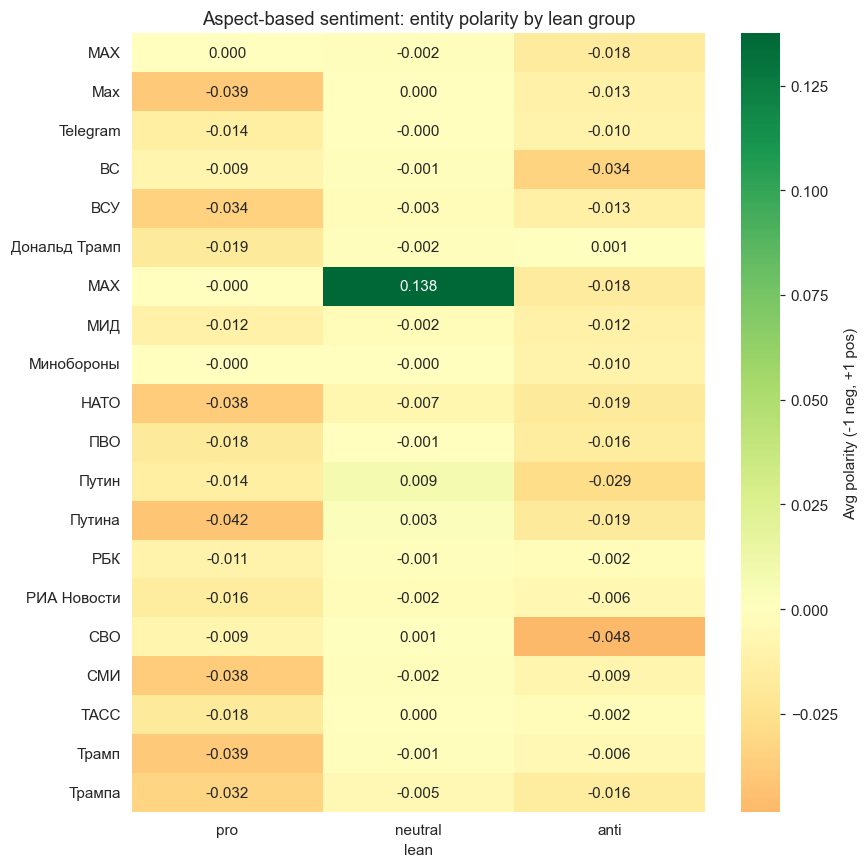

In [37]:
top_entities = (
    ents[ents["label"].isin(["PER", "ORG"])]
    .groupby("text").size()
    .sort_values(ascending=False)
    .head(20)
    .index.tolist()
)
print(f"Top entities for aspect-based sentiment: {top_entities[:10]}")

ent_sent = ents[ents["text"].isin(top_entities)].merge(
    sent[["channel_username", "msg_id", "label", "lean"]],
    on=["channel_username", "msg_id"],
    how="inner",
    suffixes=("_ent", "_sent"),
)

polarity_map = {"positive": 1, "neutral": 0, "negative": -1}
ent_sent["polarity"] = ent_sent["label_sent"].map(polarity_map)

aspect = (
    ent_sent.groupby(["text", "lean_sent"])["polarity"]
    .agg(["mean", "count"])
    .reset_index()
)
aspect.columns = ["entity", "lean", "avg_polarity", "n_mentions"]
aspect = aspect[aspect["n_mentions"] >= 50]

pivot = aspect.pivot_table(index="entity", columns="lean", values="avg_polarity", fill_value=0)
pivot = pivot.reindex(columns=["pro", "neutral", "anti"])

fig, ax = plt.subplots(figsize=(8, max(5, len(pivot) * 0.4)))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", center=0,
            cbar_kws={"label": "Avg polarity (-1 neg, +1 pos)"}, ax=ax)
ax.set_title("Aspect-based sentiment: entity polarity by lean group")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "aspect_sentiment_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()

The aspect-based heatmap reveals what raw sentiment obscures. The differences are small in absolute terms — a floor effect from the neutral-dominated sentiment model — but directionally consistent: each side is slightly more negative toward the symbols of its out-group (anti-Kremlin channels toward special military operation and Putin; pro-Kremlin channels toward Ukrainian military forses and NATO). This directional split is a weak but coherent signature of narrative polarization, which the topic and entity-network analyses show far more clearly.

A methodological note: the NER model treats Russian case inflections as
separate entities (e.g. "Trump" and "Trumpa" in nominative vs. accusative).
A production system would need lemmatization or entity linking to merge these;
for our purposes the top-entity list still captures the main actors correctly.

## 3.2 Emotion Analysis

The emotion model (`cointegrated/rubert-tiny2-cedr-emotion-detection`) assigns
one of six labels: joy, sadness, anger, fear, surprise, or no_emotion.
As with sentiment, the majority (~92%) receive `no_emotion`. We focus
on the remaining 8% where a specific emotion was detected.

### 3.2.1 Emotion distribution

Emotion distribution:
label
no_emotion    375069
anger          15469
joy            10120
surprise        4007
fear            1861
sadness         1531
Name: count, dtype: int64

Messages with detected emotion: 32,988 (8.1%)


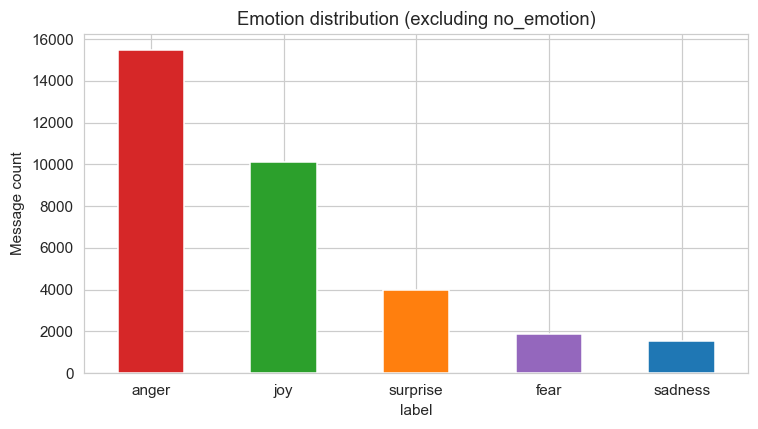

In [38]:
emo_counts = emo["label"].value_counts()
print("Emotion distribution:")
print(emo_counts)

emo_active = emo[emo["label"] != "no_emotion"].copy()
print(f"\nMessages with detected emotion: {len(emo_active):,} ({len(emo_active)/len(emo)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
emo_colors = {"anger": "#d62728", "joy": "#2ca02c", "surprise": "#ff7f0e",
              "fear": "#9467bd", "sadness": "#1f77b4"}
active_counts = emo_active["label"].value_counts()
active_counts.plot.bar(color=[emo_colors.get(l, "#999") for l in active_counts.index], ax=ax)
ax.set_title("Emotion distribution (excluding no_emotion)")
ax.set_ylabel("Message count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "emotion_distribution.png", dpi=140)
plt.show()

### 3.2.2 Emotion profiles by lean (radar chart)

We compare the emotional profiles of pro-Kremlin, anti-Kremlin, and neutral channels
using a radar chart.

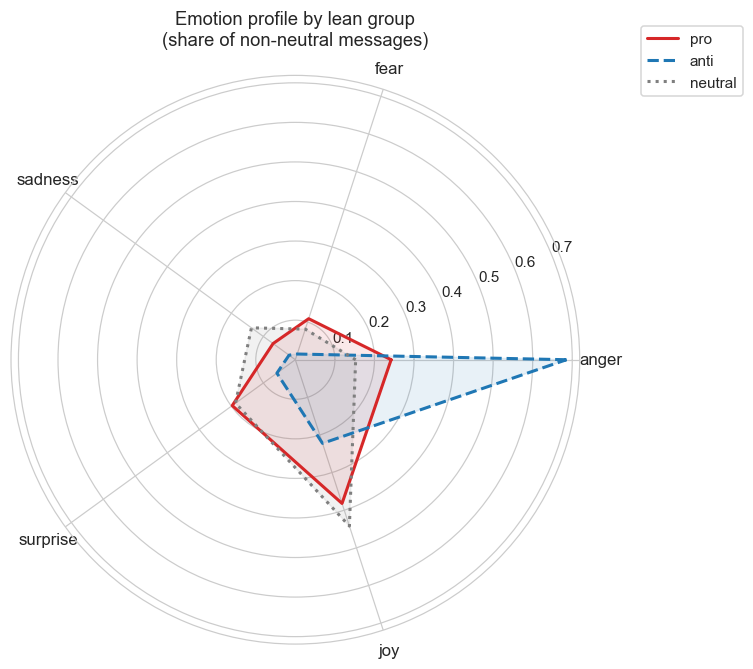


Emotion proportions by lean (%):
label    anger  fear  sadness  surprise   joy
lean                                         
anti      68.5   1.5      2.0       5.8  22.2
mixed      7.9   3.4      5.1      13.0  70.7
neutral   15.2   8.1     13.7      18.7  44.2
pro       24.2  10.9      7.0      19.7  38.2


In [39]:
from math import pi

emo_active["lean"] = emo_active["channel_username"].map(lean_map)
emo_props = (
    emo_active.groupby(["lean", "label"]).size()
    .unstack(fill_value=0)
)
emo_props = emo_props.div(emo_props.sum(axis=1), axis=0)

emotion_order = ["anger", "fear", "sadness", "surprise", "joy"]
emo_props = emo_props.reindex(columns=emotion_order, fill_value=0)

categories = emo_props.columns.tolist()
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
lean_style = {"pro": ("#d62728", "-"), "anti": ("#1f77b4", "--"), "neutral": ("#7f7f7f", ":")}
for lean_val in ["pro", "anti", "neutral"]:
    if lean_val not in emo_props.index:
        continue
    values = emo_props.loc[lean_val].tolist()
    values += values[:1]
    color, ls = lean_style[lean_val]
    ax.plot(angles, values, ls, linewidth=2, label=lean_val, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title("Emotion profile by lean group\n(share of non-neutral messages)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(OUT_DIR / "emotion_radar.png", dpi=140, bbox_inches="tight")
plt.show()

print("\nEmotion proportions by lean (%):")
print((emo_props * 100).round(1))

The radar chart reveals a striking asymmetry. **Anti-Kremlin channels are
overwhelmingly dominated by anger (68.5%)**, dwarfing all other emotions.
Pro-Kremlin channels have a more balanced profile: anger (24.2%), joy (38.2%),
and surprise (19.7%) each play a role. Neutral outlets lean toward joy (44.2%)
and surprise (18.7%), consistent with a broader editorial mix that includes
lifestyle and sports content alongside politics.

The anti-Kremlin anger dominance likely reflects the adversarial position of
opposition media: their content is largely critical and confrontational by nature.
Pro-government channels, by contrast, alternate between aggression toward enemies
and triumphalist positive framing of domestic achievements, which explains the
more even emotional spread.

## 3.3 Named Entity Recognition + Entity Networks

NER was performed with SpaCy `ru_core_news_lg`, extracting entities of type
PER (person), ORG (organization), and LOC (location). We use these entities
in two ways: to see which actors dominate each faction's discourse, and to
build entity co-occurrence networks that reveal narrative structure.

### 3.3.1 Top entities by lean group

In [40]:
for ent_type in ["PER", "ORG", "LOC"]:
    print(f"\n=== Top {ent_type} entities ===")
    for lean_val in ["pro", "anti", "neutral"]:
        sub = ents[(ents["label"] == ent_type) & (ents["lean"] == lean_val)]
        top = sub["text"].value_counts().head(8)
        print(f"\n  {lean_val}: {', '.join(f'{name} ({cnt})' for name, cnt in top.items())}")


=== Top PER entities ===



  pro: Трамп (16720), Путин (13018), Трампа (12771), Дмитрий Никотин (5762), Зеленский (4455), Скабеева (3654), Владимир Путин (3620), Путина (3536)



  anti: Трамп (6118), Дождя (4397), Путин (4041), Путина (3811), Трампа (3524), Радіо Свобода (2963), України (2494), Зеленский (1893)



  neutral: Трамп (4372), Путин (3085), Дональд Трамп (2706), 💬 (2279), Трампа (2138), Владимир Путин (1982), Дональда Трампа (1329), Песков (1225)

=== Top ORG entities ===



  pro: ВСУ (19332), Telegram (14316), MAX (13284), СВО (11174), МАХ (11029), НАТО (9358), СМИ (7709), ВС (6917)



  anti: Telegram (8397), ТРУХА (5293), СМИ (3445), ВСУ (2949), ФСБ (2692), Минобороны (2653), Reuters (2616), НАТО (2597)



  neutral: ТАСС (17988), РБК (17150), РИА Новости (11653), Telegram (10748), Max (5312), Telegram
|
WhatsApp
|
YouTube
|
Рассылка (5025), ВСУ (4574), Минобороны (3939)

=== Top LOC entities ===



  pro: России (61632), США (57025), РФ (27835), Украины (16587), Россия (16403), Украине (15095), Ирана (15055), Иран (12163)



  anti: России (23294), США (21386), Украины (11201), РФ (7606), Украине (7110), Россия (4853), рф (4272), Ирана (4086)



  neutral: США (21394), России (17555), РФ (13513), Ирана (5516), Украины (5065), 🔸 (4958), Украине (4933), Москве (4071)


Several patterns stand out. **Trump is the most-mentioned person across all three
lean groups**, reflecting the dominance of US-Russia relations in the discourse
during our collection period. Putin ranks second in both pro and anti channels.
Among organizations, VSU (Ukrainian Armed Forces) leads in pro-Kremlin channels,
consistent with military reporting being a core function of that ecosystem. Anti-Kremlin
channels mention FSB and Reuters more often, reflecting a focus on domestic
repression and reliance on Western news agencies.

Note that SpaCy's NER does not lemmatize Russian names, so inflected forms
("Trump" / "Trumpa", "Putin" / "Putina") appear as separate entities. For the
co-occurrence analysis below, we keep them as-is since they still capture the
correct associations.

### 3.3.2 Entity co-occurrence networks

An entity co-occurrence network connects entities that appear in the same message.
By building separate networks for pro- and anti-Kremlin channels, we can compare
how each faction constructs its narrative: which actors are linked together, and
which topics are framed as connected.

In [41]:
def build_entity_cooccurrence(ents_df, lean_val, top_n=25, min_coocc=10):
    sub = ents_df[(ents_df["lean"] == lean_val) & (ents_df["label"].isin(["PER", "ORG"]))]
    top_ent_names = sub["text"].value_counts().head(top_n).index.tolist()
    sub = sub[sub["text"].isin(top_ent_names)]

    cooccur = Counter()
    for (ch, mid), grp in sub.groupby(["channel_username", "msg_id"]):
        unique = sorted(grp["text"].unique())
        if len(unique) < 2:
            continue
        for a, b in combinations(unique, 2):
            cooccur[(a, b)] += 1

    G_ent = nx.Graph()
    for (a, b), w in cooccur.items():
        if w >= min_coocc:
            G_ent.add_edge(a, b, weight=w)

    freq = sub["text"].value_counts().to_dict()
    for n in G_ent.nodes():
        G_ent.nodes[n]["freq"] = freq.get(n, 1)
    return G_ent


G_ent_pro  = build_entity_cooccurrence(ents, "pro",  top_n=25, min_coocc=10)
G_ent_anti = build_entity_cooccurrence(ents, "anti", top_n=25, min_coocc=10)

print(f"Pro entity network:  {G_ent_pro.number_of_nodes()} nodes, {G_ent_pro.number_of_edges()} edges")
print(f"Anti entity network: {G_ent_anti.number_of_nodes()} nodes, {G_ent_anti.number_of_edges()} edges")

Pro entity network:  25 nodes, 280 edges
Anti entity network: 25 nodes, 235 edges


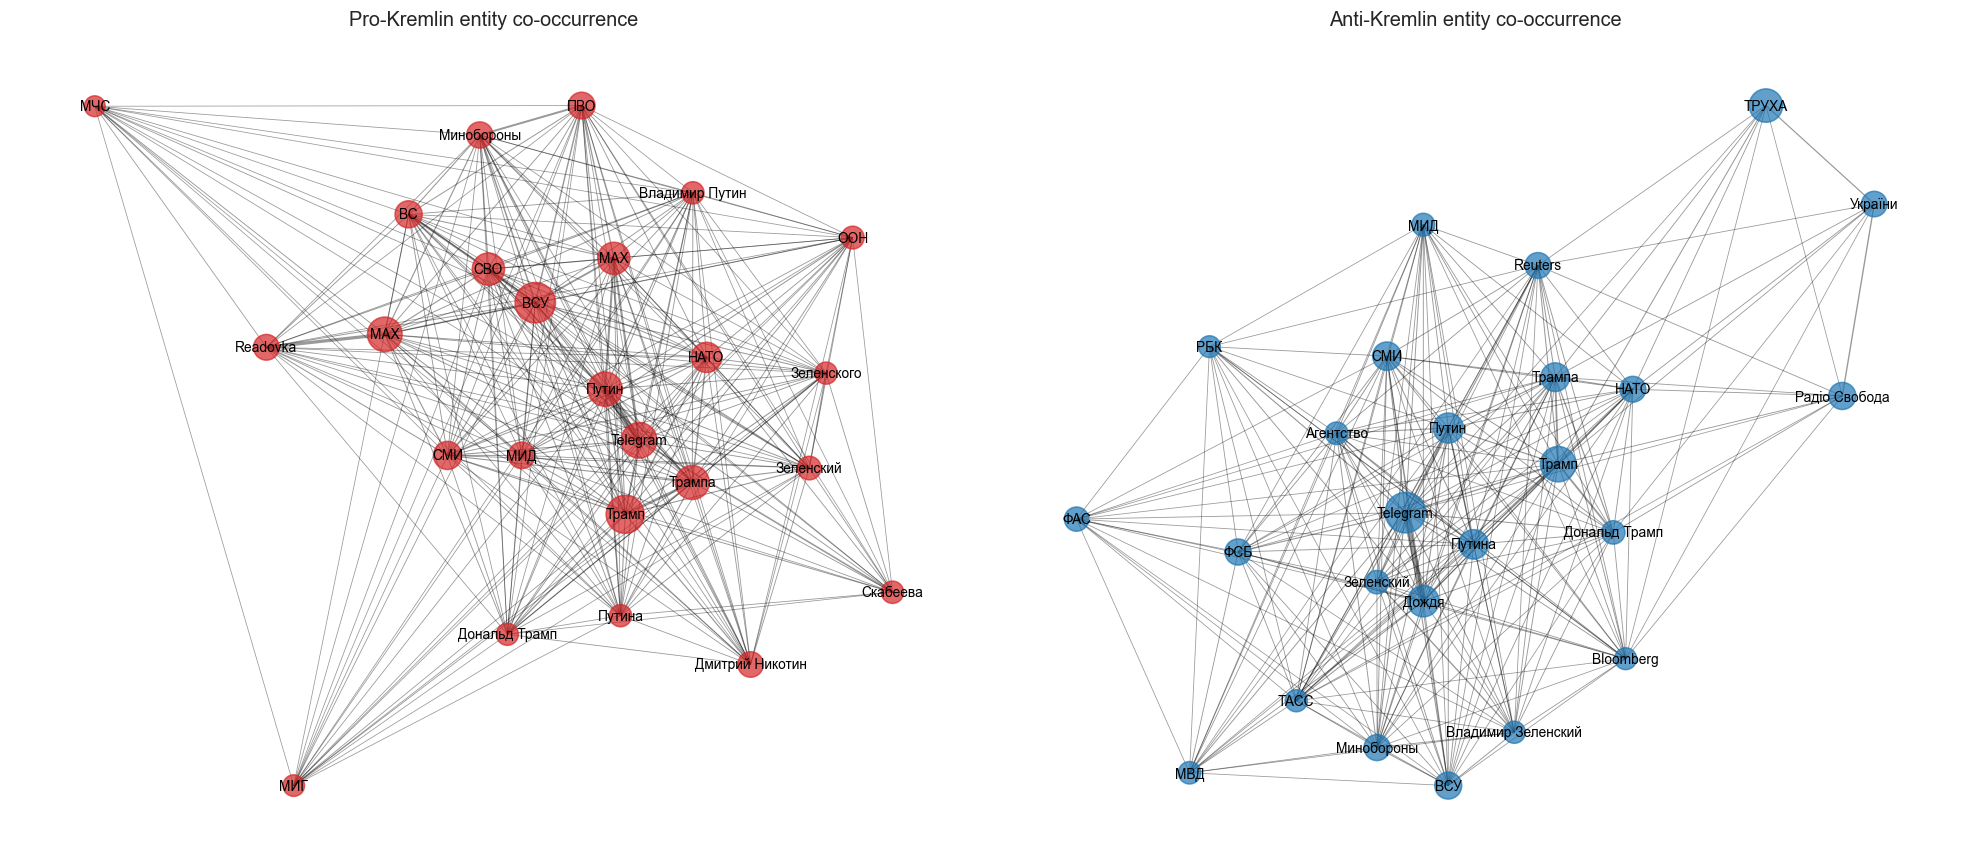

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, G_ent, title, color in [
    (axes[0], G_ent_pro,  "Pro-Kremlin entity co-occurrence", "#d62728"),
    (axes[1], G_ent_anti, "Anti-Kremlin entity co-occurrence", "#1f77b4"),
]:
    if G_ent.number_of_nodes() == 0:
        ax.set_title(f"{title}\n(no data)")
        ax.set_axis_off()
        continue

    pos = nx.spring_layout(G_ent, k=1.5, seed=RNG_SEED)
    freqs = [G_ent.nodes[n].get("freq", 100) for n in G_ent.nodes()]
    max_freq = max(freqs) if freqs else 1
    node_sizes = [100 + 600 * (f / max_freq) for f in freqs]

    weights = [G_ent[u][v]["weight"] for u, v in G_ent.edges()]
    max_w = max(weights) if weights else 1
    edge_widths = [0.5 + 3 * (w / max_w) for w in weights]

    nx.draw_networkx_nodes(G_ent, pos, node_size=node_sizes, node_color=color,
                           alpha=0.7, ax=ax)
    nx.draw_networkx_edges(G_ent, pos, width=edge_widths, alpha=0.4, ax=ax)
    nx.draw_networkx_labels(G_ent, pos, font_size=9, ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()

plt.tight_layout()
plt.savefig(OUT_DIR / "entity_cooccurrence_pro_vs_anti.png", dpi=140, bbox_inches="tight")
plt.show()

The pro-Kremlin entity network is denser (280 edges vs. 235), reflecting a more
tightly integrated narrative. Both networks center on Trump and Putin, but the
surrounding actors differ: pro-Kremlin channels connect military entities (VSU,
AKHMAT, Ministry of Defense) to political figures, while anti-Kremlin channels
give more weight to media organizations (Reuters, Dozhd) and domestic
security agencies (FSB). The structural difference between these two graphs is
a visual demonstration of how the same geopolitical events are narrated through
different actor-networks.

## 3.4 Topic Modeling

We use BERTopic with `cointegrated/rubert-tiny2` embeddings to discover latent
topics in a 30K-message sample. BERTopic clusters documents in embedding space
(via UMAP + HDBSCAN) and then extracts representative terms per cluster.

**Note:** requires `pip install bertopic sentence-transformers`.

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2026-06-05 18:13:45,493 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/938 [00:00<?, ?it/s]

2026-06-05 18:15:02,271 - BERTopic - Embedding - Completed ✓


...

2026-06-05 18:15:27,861 - BERTopic - Cluster - Start clustering the reduced embeddings


2026-06-05 18:15:30,798 - BERTopic - Cluster - Completed ✓


2026-06-05 18:15:30,804 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-06-05 18:15:33,384 - BERTopic - Representation - Completed ✓


Topics found: 64
    Topic  Count                                    Name  \
0      -1  14100                         -1_на_что_не_по   
1       0   4968                      0_сша_что_не_трамп   
2       1   1449                   1_та_що_україна_труха   
3       2    834             2_vpn_telegram_интернета_не   
4       3    748                     3_года_на_рост_году   
5       4    694      4_результате_селе_атаки_пострадали   
6       5    615                         5_не_то_это_что   
7       6    503                    6_рублей_суд_млн_экс   
8       7    346                     7_фильм_на_книги_из   
9       8    306               8_нефти_нефть_на_баррелей   
10      9    295                       9_может_от_на_для   
11     10    240     10_группировки_всу_войск_противника   
12     11    238  11_великой_победы_отечественной_россии   
13     12    213      12_спортсменов_играх_спорта_италии   
14     13    204               13_колонии_суд_года_годам   

                      

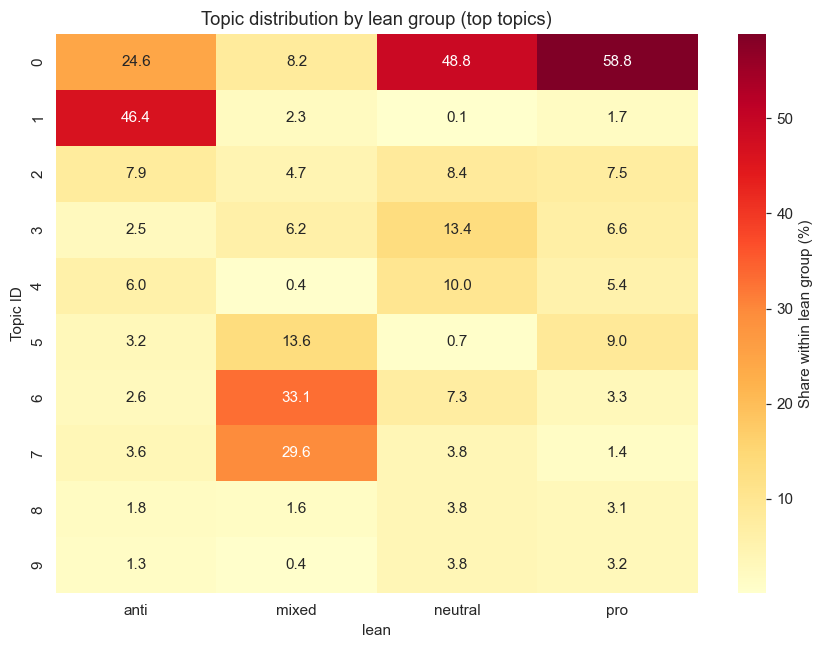

In [43]:
try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer

    TOPIC_SAMPLE_SIZE = 30_000
    topic_docs = (
        messages[messages["text_clean"].str.len() > 80]
        .sample(min(TOPIC_SAMPLE_SIZE, len(messages)), random_state=RNG_SEED)
    )
    topic_texts = topic_docs["text_clean"].tolist()
    topic_leans = topic_docs["channel_username"].map(lean_map).tolist()

    embedding_model = SentenceTransformer("cointegrated/rubert-tiny2")
    topic_model = BERTopic(
        embedding_model=embedding_model,
        language="russian",
        min_topic_size=30,
        verbose=True,
    )
    topics, probs = topic_model.fit_transform(topic_texts)

    print(f"Topics found: {len(set(topics)) - 1}")
    print(topic_model.get_topic_info().head(15))

    topic_docs["topic"] = topics
    topic_docs["lean"] = topic_leans

    top_topics = [t for t in topic_model.get_topic_info()["Topic"].head(11) if t != -1]
    topic_lean = pd.crosstab(
        topic_docs[topic_docs["topic"].isin(top_topics)]["topic"],
        topic_docs[topic_docs["topic"].isin(top_topics)]["lean"],
        normalize="columns"
    ) * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(topic_lean, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
                cbar_kws={"label": "Share within lean group (%)"})
    ax.set_title("Topic distribution by lean group (top topics)")
    ax.set_ylabel("Topic ID")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "topic_heatmap.png", dpi=140)
    plt.show()

except ImportError:
    print("BERTopic not installed. Run: pip install bertopic sentence-transformers")
except Exception as e:
    print(f"Topic modeling failed: {e}")

BERTopic identified 64 topics plus an outlier cluster (topic −1, ~14K messages). The largest substantive topic (Topic 0: сша, трамп, иран) captures US–Russia–Iran geopolitics and is concentrated in pro-Kremlin (58.8%) and neutral (48.8%) channels — the shared news agenda. The most polarized topic is Topic 1 (Ukrainian-language: україна, труха, надіслати), which is almost exclusive to anti-Kremlin channels (46.4%) and virtually absent from pro (1.7%), reflecting Ukrainian-language outlets like Труха and Радіо Свобода. The "mixed" group has a distinctive signature in Topic 6 (legal/financial: рублей, суд, млн, 33.1%) and Topic 7 (films/books, 29.6%), consistent with the lifestyle-plus-politics profile of controlled-opposition channels like Sobchak. Other distinctive topics include oil/energy markets (Topic 8) and strikes/casualties (Topic 4). The heatmap confirms that topic structure aligns with political lean beyond the shared general-news discourse.

## 3.5 LLM-as-Judge: Propaganda Technique Detection *(local Ollama / qwen2.5:7b-instruct)*

Loaded cached LLM annotations: 50 rows (model=qwen2.5:7b-instruct-q5_K_M)
             channel     lean                              techniques    framing
0         mod_russia      pro                                  [none]    neutral
1      MedvedevVesti      pro        [loaded_language, false_dilemma]  aggressor
2  margaritasimonyan      pro  [loaded_language, appeal_to_authority]    neutral
3         meduzalive     anti                          [whataboutism]    neutral
4          bazabazon      pro       [loaded_language, appeal_to_fear]     victim
5       SolovievLive      pro                                  [none]    neutral
6         kommersant  neutral                                  [none]    neutral
7      Sandymustache     anti  [loaded_language, appeal_to_authority]    neutral
8     interfaxonline  neutral                                  [none]    neutral
9       readovkanews      pro       [loaded_language, appeal_to_fear]    neutral

Propaganda techniques by lean grou

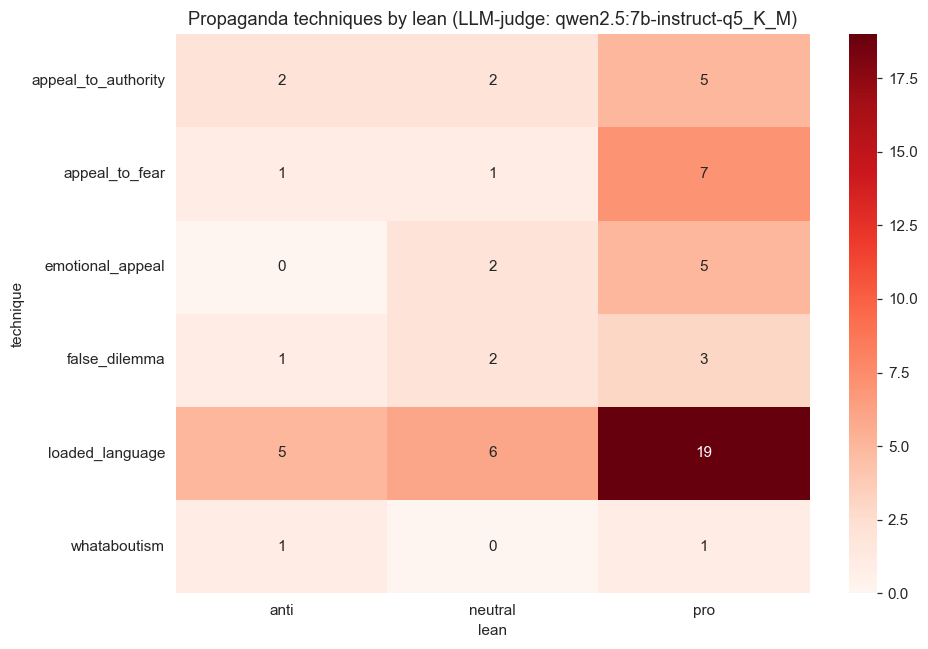

In [44]:
# LLM-as-Judge: Propaganda technique detection via local Ollama (qwen2.5:7b-instruct)
# Cached: if outputs/llm_annotations.pkl exists it is loaded (so a full "Run All"
# does not need to hold the 7B model + the whole corpus in RAM at once).
# Delete the pkl to re-annotate live against Ollama.
import json as _json

OLLAMA_MODEL = "qwen2.5:7b-instruct-q5_K_M"
_cache = OUT_DIR / "llm_annotations.pkl"

SYSTEM_PROMPT = (
    "You are an expert in propaganda analysis. For the given Russian-language "
    "Telegram message, identify which propaganda techniques are used (if any). "
    'Respond ONLY with a JSON object: {"techniques": ["technique1", "technique2"], '
    '"framing": "victim|aggressor|neutral"}. '
    "Possible techniques: appeal_to_fear, ad_hominem, whataboutism, loaded_language, "
    "bandwagon, false_dilemma, name_calling, appeal_to_authority, emotional_appeal, none."
)


def _annotate_with_ollama(sample_df):
    import openai
    client = openai.OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")
    rows = []
    for _, row in tqdm(list(sample_df.iterrows()), desc="LLM-judge (Ollama)"):
        try:
            resp = client.chat.completions.create(
                model=OLLAMA_MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": str(row["text_clean"])[:1000]},
                ],
                temperature=0,
                max_tokens=200,
                response_format={"type": "json_object"},
            )
            rows.append({
                "channel": row["channel_username"],
                "lean": row["lean"],
                "response": resp.choices[0].message.content,
            })
        except Exception as e:
            print(f"LLM error: {e}")
            break
    return pd.DataFrame(rows)


if _cache.exists():
    llm_df = pd.read_pickle(_cache)
    print(f"Loaded cached LLM annotations: {len(llm_df)} rows (model={OLLAMA_MODEL})")
else:
    _sample = (
        messages[messages["text_clean"].str.len() > 200]
        .sample(min(300, len(messages)), random_state=RNG_SEED)
        .head(50)
        .copy()
    )
    _sample["lean"] = _sample["channel_username"].map(lean_map)
    llm_df = _annotate_with_ollama(_sample)
    if len(llm_df):
        llm_df.to_pickle(_cache)

if len(llm_df):
    def _parse(r):
        try:
            return _json.loads(r)
        except Exception:
            return {}

    parsed = llm_df["response"].apply(_parse)
    llm_df["techniques"] = parsed.apply(
        lambda d: d.get("techniques", []) if isinstance(d, dict) else []
    )
    llm_df["framing"] = parsed.apply(
        lambda d: d.get("framing") if isinstance(d, dict) else None
    )
    print(llm_df[["channel", "lean", "techniques", "framing"]].head(10).to_string())

    tech_rows = [
        {"lean": r["lean"], "technique": t}
        for _, r in llm_df.iterrows()
        for t in r["techniques"]
        if t and t != "none"
    ]
    if tech_rows:
        tech_df = pd.DataFrame(tech_rows)
        tech_by_lean = pd.crosstab(tech_df["technique"], tech_df["lean"])
        print("\nPropaganda techniques by lean group:")
        print(tech_by_lean.to_string())

        fig, ax = plt.subplots(figsize=(9, 6))
        sns.heatmap(tech_by_lean, annot=True, fmt="d", cmap="Reds", ax=ax)
        ax.set_title(f"Propaganda techniques by lean (LLM-judge: {OLLAMA_MODEL})")
        plt.tight_layout()
        plt.savefig(OUT_DIR / "llm_propaganda_techniques.png", dpi=140)
        plt.show()
else:
    print("No LLM annotations available (Ollama unreachable and no cache).")


The most frequently detected technique is loaded language, which appears in pro-Kremlin channels nearly 4x more often than in anti-Kremlin ones (19 vs. 5). Appeal to fear is almost exclusively a pro-government tool (7 vs. 1). This is a striking result when combined with the sentiment findings from Section 3.1: the RuBERT sentiment model classified most pro-Kremlin messages as neutral, yet the LLM detects loaded language and emotional manipulation in the same texts. This gap directly confirms the "pseudo-neutral register" hypothesis — state-aligned channels disguise propaganda techniques within a formally objective tone that automated sentiment classifiers do not catch. The small sample size (n=50) limits statistical power, but the pattern is clear enough to warrant further investigation with a larger subsample.

---
# Section 4: Additional Visualizations

This section brings together supplementary visualizations that combine network
and content findings. Some plots from earlier sections (the forwarding graph,
the coordination heatmap, the entity co-occurrence networks) are the primary
network and content visuals. Here we add word clouds, ego networks, and a
temporal posting heatmap.

## 4.1 Word Clouds by Lean Group (TF-IDF weighted)

Raw word frequency is dominated by common words. We use TF-IDF weighting to
surface terms that are *distinctively frequent* in each lean group compared
to the full corpus.

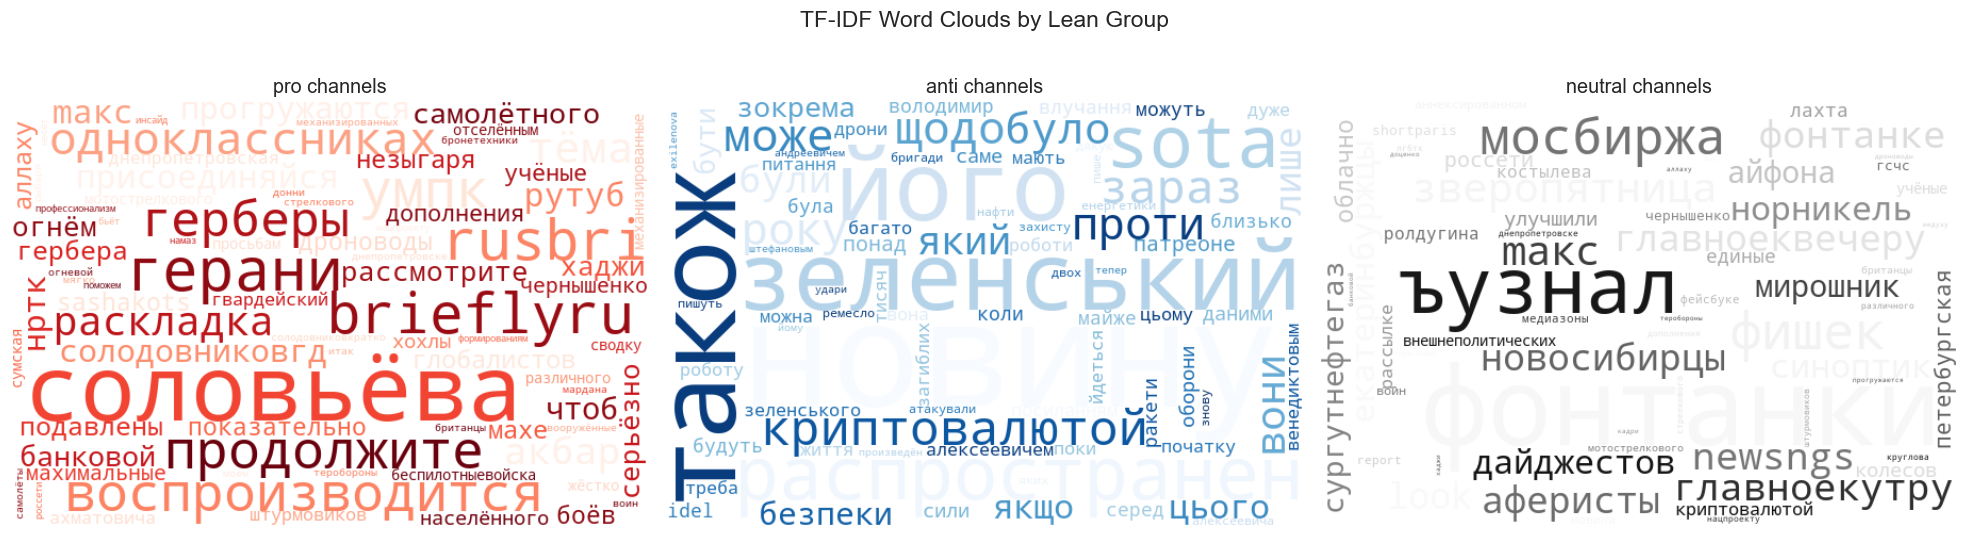

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "wordcloud", "-q"])
    from wordcloud import WordCloud

# Channel names and display names as stopwords
channel_stopwords = set(seeds["username"].str.lower()) | set(
    seeds["display_name"].fillna("").str.lower().str.split().explode()
)
# Also common Russian stopwords and short tokens
extra_stops = {"это", "что", "для", "как", "при", "или", "его", "она",
               "они", "все", "уже", "так", "там", "тут", "еще", "без",
               "после", "также", "может", "будет", "если", "быть", "был",
               "была", "были", "того", "этом", "этой", "свои", "свой",
               "который", "которые", "которая", "которое", "более",
               "только", "нужно", "надо", "https", "http", "www", "com",
               "подписаться", "подписывайтесь", "оставляй", "дежурными",
               "english", "erid", "дснв", "барр"}
all_stops = list(channel_stopwords | extra_stops)

lean_texts = (
    messages[messages["text_clean"].str.len() > 50]
    .assign(lean=lambda df: df["channel_username"].map(lean_map))
    .dropna(subset=["lean"])
    .groupby("lean")["text_clean"]
    .apply(lambda x: " ".join(x.sample(min(20000, len(x)), random_state=RNG_SEED)))
    .to_dict()
)

leans_order = ["pro", "anti", "neutral"]
corpus = [lean_texts.get(l, "") for l in leans_order]
tfidf = TfidfVectorizer(max_features=500, min_df=1, max_df=0.95,
                         stop_words=all_stops, token_pattern=r"(?u)\b[а-яёa-z]{4,}\b")
tfidf_matrix = tfidf.fit_transform(corpus)
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
wc_colors = {"pro": "Reds", "anti": "Blues", "neutral": "Greys"}

for idx, lean_val in enumerate(leans_order):
    scores = dict(zip(feature_names, tfidf_matrix[idx].toarray().flatten()))
    scores = {k: v for k, v in scores.items() if v > 0}

    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap=wc_colors[lean_val], max_words=80)
    wc.generate_from_frequencies(scores)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f"{lean_val} channels", fontsize=13)
    axes[idx].axis("off")

plt.suptitle("TF-IDF Word Clouds by Lean Group", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "wordclouds_tfidf.png", dpi=140, bbox_inches="tight")
plt.show()

The word clouds now show content vocabulary rather than channel names. Pro-Kremlin channels are dominated by military terminology: герани and герберы (names for Shahed-type drones), УМПК (guided aerial bombs), беспилотные (unmanned), боёв and населённого (combat and populated areas). The presence of the slur "хохлы" is also distinctive for this group. Anti-Kremlin channels are overwhelmingly Ukrainian-language: також, зокрема, щодо, який, проти, якщо are common Ukrainian function words, and "Зеленський" appears in its Ukrainian spelling. This confirms that a significant portion of anti-Kremlin content in our dataset originates from Ukrainian-language media. Neutral channels feature financial and regional terms: Мосбиржа (Moscow Exchange), Сургутнефтегаз, Норникель (major Russian companies), петербургская, Новосибирцы (city-level reporting), reflecting the economic and local news focus of this cluster. The three clouds together illustrate a clean thematic separation: war, Ukrainian politics, and domestic business/regional news.

## 4.2 Ego Networks of Top Bridge Channels

An ego network shows a single channel and all its direct forwarding
connections. We plot the top 5 channels by betweenness centrality, which
are the main bridges between communities.

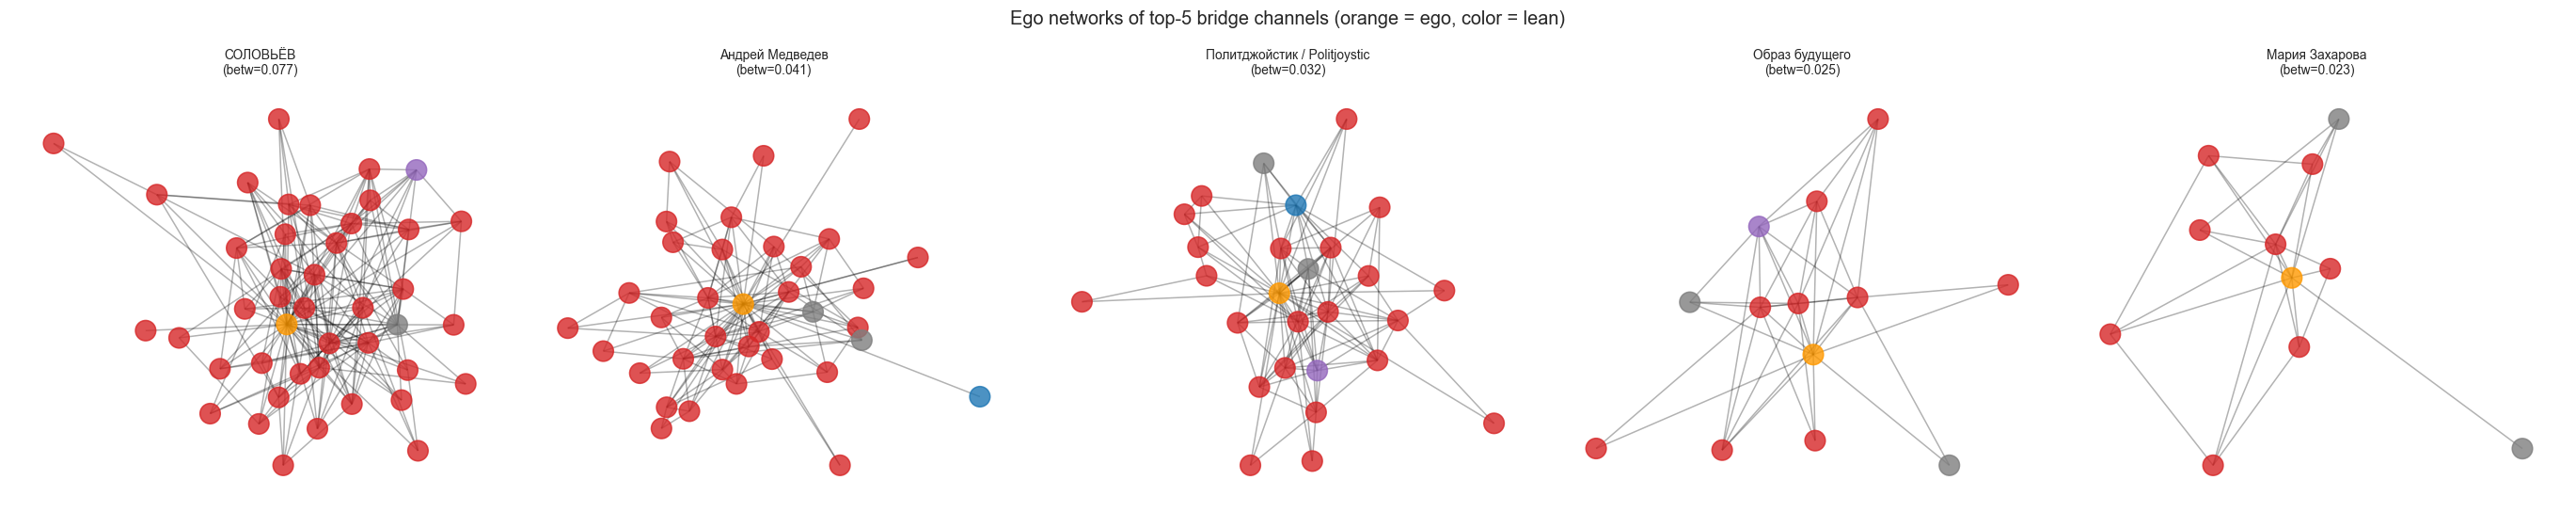

In [46]:
top_bridges = metrics.nlargest(5, "betweenness").index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, ego_node in zip(axes, top_bridges):
    ego_g = nx.ego_graph(G_A.to_undirected(), ego_node, radius=1)
    pos = nx.spring_layout(ego_g, seed=RNG_SEED)
    node_colors_ego = []
    for n in ego_g.nodes():
        if n == ego_node:
            node_colors_ego.append("#ff9900")
        else:
            node_colors_ego.append(lean_colors.get(
                ego_g.nodes[n].get("lean", "unknown"), "#cccccc"))

    nx.draw_networkx_nodes(ego_g, pos, node_color=node_colors_ego,
                           node_size=200, alpha=0.8, ax=ax)
    nx.draw_networkx_edges(ego_g, pos, alpha=0.3, ax=ax)
    # Label only ego node
    name = metrics.loc[ego_node, "display_name"] if ego_node in metrics.index else ego_node
    ax.set_title(f"{name}\n(betw={metrics.loc[ego_node, 'betweenness']:.3f})",
                 fontsize=9)
    ax.set_axis_off()

plt.suptitle("Ego networks of top-5 bridge channels (orange = ego, color = lean)", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "ego_networks_bridges.png", dpi=140, bbox_inches="tight")
plt.show()

The ego networks confirm why these channels score high on betweenness. Solovyov has the densest neighbourhood (most connections), but it is almost entirely red (pro) — he is a hub within the pro-Kremlin cluster rather than a true cross-community bridge. Politjoystic is the most genuinely bridging channel: its ego network contains red, blue, grey, and purple nodes, meaning it connects pro, anti, neutral, and mixed channels. This aligns with its role as a political commentary channel that aggregates content from multiple sources regardless of lean. Zakharova has a small, tight ego network of exclusively pro-Kremlin nodes, consistent with her institutional role as MID spokesperson.

## 4.3 Temporal Posting Heatmap

This heatmap shows daily posting volume for the top 30 most active channels.
Vertical stripes of synchronized activity are a visual fingerprint of
coordinated behavior: if multiple channels spike on the same day, they are
likely reacting to (or orchestrating) the same narrative push.

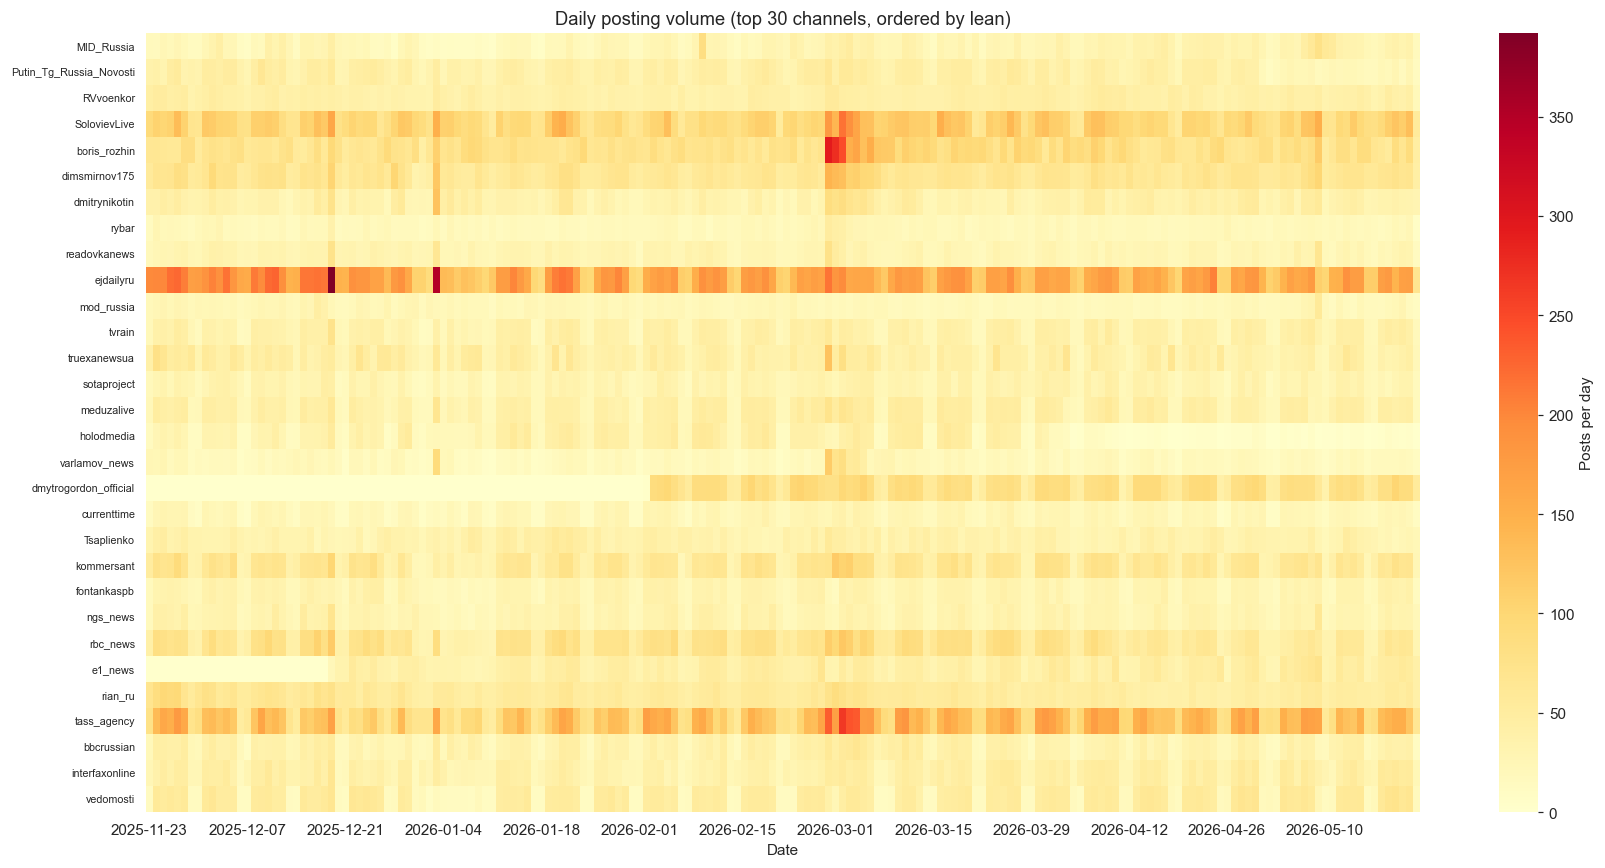

In [47]:
top_active = messages.groupby("channel_username").size().nlargest(30).index.tolist()
daily = (
    messages[messages["channel_username"].isin(top_active)]
    .assign(date=lambda df: df["timestamp"].dt.date)
    .groupby(["channel_username", "date"]).size()
    .unstack(fill_value=0)
)

# Order channels by lean then by volume
order_map = {"pro": 0, "anti": 1, "neutral": 2, "mixed": 3}
daily["_sort"] = daily.index.map(lambda x: order_map.get(lean_map.get(x, ""), 9))
daily = daily.sort_values("_sort").drop(columns=["_sort"])

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(daily, cmap="YlOrRd", cbar_kws={"label": "Posts per day"},
            xticklabels=14, yticklabels=True, ax=ax)
ax.set_title("Daily posting volume (top 30 channels, ordered by lean)")
ax.set_xlabel("Date")
ax.set_ylabel("")
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(OUT_DIR / "temporal_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()

The temporal heatmap reveals several patterns. ejdailyru stands out as the most prolific channel, maintaining a consistently high volume throughout the 6-month window (the dark red band). tass_agency and rian_ru show steady output typical of wire services. The most interesting feature is dmytrogordon_official, which appears to have joined the dataset in mid-February 2026, showing an abrupt onset of activity. Several vertical bright bands are visible around early March 2026, indicating days when multiple channels across different lean groups spiked simultaneously — likely driven by a major news event. The absence of strong vertical bands in the anti-Kremlin section (lower portion) suggests that opposition channels operate more independently, while pro-Kremlin channels (upper portion) show more synchronized posting.

## 4.4 Information Flow Between Lean Groups (Sankey)

We summarize the total forwarding volume between lean groups as a Sankey
diagram. This shows the direction and magnitude of information exchange
between pro, anti, neutral, and mixed clusters.

In [48]:
try:
    import plotly.graph_objects as go

    # Aggregate forwarding by lean group
    flow = (
        fwd.assign(
            src_lean=fwd["forwarded_from"].map(lean_map),
            dst_lean=fwd["channel_username"].map(lean_map),
        )
        .dropna(subset=["src_lean", "dst_lean"])
        .groupby(["src_lean", "dst_lean"]).size()
        .reset_index(name="count")
    )

    labels = ["pro (source)", "anti (source)", "neutral (source)", "mixed (source)",
              "pro (target)", "anti (target)", "neutral (target)", "mixed (target)"]
    label_map_src = {"pro": 0, "anti": 1, "neutral": 2, "mixed": 3}
    label_map_dst = {"pro": 4, "anti": 5, "neutral": 6, "mixed": 7}
    colors_sankey = ["#d62728", "#1f77b4", "#7f7f7f", "#9467bd",
                     "#d62728", "#1f77b4", "#7f7f7f", "#9467bd"]

    fig = go.Figure(go.Sankey(
        node=dict(pad=15, thickness=20, label=labels, color=colors_sankey),
        link=dict(
            source=[label_map_src[r["src_lean"]] for _, r in flow.iterrows()],
            target=[label_map_dst[r["dst_lean"]] for _, r in flow.iterrows()],
            value=flow["count"].tolist(),
            color=["rgba(200,200,200,0.4)"] * len(flow),
        ),
    ))
    fig.update_layout(title_text="Information flow between lean groups (forwarding volume)",
                      font_size=12, width=800, height=500)
    fig.write_image(OUT_DIR / "sankey_flow.png", scale=2)
    fig.show()

except ImportError:
    print("Plotly not available. Install with: pip install plotly kaleido")
except Exception as e:
    print(f"Sankey diagram failed: {e}")
    print("Falling back to a table view:")
    flow_table = fwd.assign(
        src_lean=fwd["forwarded_from"].map(lean_map),
        dst_lean=fwd["channel_username"].map(lean_map),
    ).dropna(subset=["src_lean", "dst_lean"]).groupby(["src_lean", "dst_lean"]).size().unstack(fill_value=0)
    print(flow_table)

The Sankey diagram makes the echo chamber structure starkly visible. The dominant flow by far is pro→pro: the vast majority of forwarding occurs within the pro-Kremlin ecosystem. Anti→anti forwarding is the second largest, but substantially smaller. Cross-lean flows exist but are thin: some pro content reaches neutral outlets, and vice versa, but direct pro↔anti forwarding is minimal. This confirms the community detection findings from Section 2.3: the network is structurally polarized, with information circulating within political camps rather than across them.

---
# Summary of Outputs

**Network analysis (Section 2):**
- `graph_A_forwarding.png` / `.graphml` : forwarding network colored by lean
- `graph_B_url_cosharing.graphml` : URL co-sharing network
- `graph_C_temporal_coposting.graphml` : temporal co-posting network
- `degree_distribution.png` : power-law fit
- `model_comparison.png` : comparison vs Erdos-Renyi / Barabasi-Albert
- `communities_louvain.png` : community structure
- `coordination_heatmap.png` : CIB detection heatmap

**Content analysis (Section 3):**
- `sentiment_distribution.png` : overall sentiment breakdown
- `sentiment_by_lean.png` : sentiment composition by lean group
- `sentiment_timeline.png` : weekly negative sentiment trends
- `aspect_sentiment_heatmap.png` : entity-level polarity by lean
- `emotion_distribution.png` : emotion breakdown (non-neutral)
- `emotion_radar.png` : emotion profiles by lean (radar chart)
- `entity_cooccurrence_pro_vs_anti.png` : narrative structure comparison

**Additional visualizations (Section 4):**
- `wordclouds_tfidf.png` : TF-IDF word clouds per lean group
- `ego_networks_bridges.png` : ego networks of top bridge channels
- `temporal_heatmap.png` : daily posting heatmap for coordination detection
- `sankey_flow.png` : information flow between lean groups

In [49]:
conn.close()
print(f"\nNotebook complete. Outputs in {OUT_DIR.resolve()}")


Notebook complete. Outputs in C:\Users\goog\Desktop\WSA_project\WSA_project\outputs
